# April Forecast — Prophet Component Decomposition (world-level)

**Purpose.** Track the production April 2026 desktop-DAU world-level forecast and decompose it into Prophet's constituent components — trend, yearly seasonality, weekly seasonality, and mozaic's `holiday_smart` adjustment. One component per section; same 3-pane (28-day MA / 7-day MA / daily) layout from the country diagnosis notebook.

**Why this scope.** The country and OS diagnostics showed that sub-aggregates are constrained by reconciliation to the world-level fit, so divergences below the world level are confounded with the world fit's error. This notebook isolates the world fit and asks: which Prophet component is the source of any mis-fit?

**Two data sources, used for different things.**

- **Production parquet** (`mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet`, the `(ALL, ALL)` row) — the daily forecast values that ultimately drive every downstream artifact (composite CSV, leadership chart). This is `median(clip(samples + holiday_smart))` from mozaic's `to_df()`. **Used as the "full forecast" line everywhere it appears (§1 and §7 layers 4–5).**
- **Saved Prophet model from the metric-mozaic pickle** (`mozaic_objects.legacy_desktop.2026-04-01.pkl`) — re-run `predict()` to access the decomposed components (trend, yearly, weekly) that the parquet doesn't expose individually. **Used for the component-decomposition lines (§2–§5, §7 layers 1–3, §8–§10).**

The two views differ in a few small ways: Prophet's `yhat` is `mean(samples)` while the parquet uses `median(clip(samples + holiday_smart))`. For most days these are within ~80K (verified in §11). The "production" line in §1 and §7-L5 is the parquet path because that's what leadership sees.

**Coordinate-system note.** This Prophet fit uses `growth="linear"`, `seasonality_mode="multiplicative"`, and a `log(y + 1)` transform of the input series (selected automatically by `mozaic.models.desktop_forecast_model` when the data shows variance scaling with level). All components below are in **log-space multipliers**; we back-transform to DAU before plotting. For each component plot we draw three lines:

- raw actuals (DAU)
- trend-only baseline in DAU: `exp(trend) − 1`
- trend + this component in DAU: `exp(trend × (1 + component_factor)) − 1`

The gap between line 2 and line 3 is the *isolated DAU contribution of that component*; the gap between line 1 and line 3 is what's left unexplained when you only use trend plus that one component.

**Holiday note.** Prophet itself has *no* internal holiday term on this fit (`mozaic/core.py:74-80` feeds it `holiday_detrended_historical_data`, and `mozaic/models.py:9-90` does not call `add_country_holidays` or pass `holidays=`). Mozaic's `holiday_smart` (`forecasted_holiday_impacts`, fit in `core.py:_fit_holiday_effects`) is the only holiday term in the production forecast.


In [1]:
# [setup]
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from google.cloud import bigquery
from plotly.subplots import make_subplots

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 110

# Walk up to the repo root so relative paths resolve regardless of launch context.
_here = Path.cwd()
for _candidate in (_here, *_here.parents):
    if (_candidate / "src" / "mozaic_daily").is_dir():
        os.chdir(_candidate)
        break
print(f"Working directory: {Path.cwd()}")

# --- Paths ---
PKL_PATH = (
    "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/"
    "mozaic_objects.legacy_desktop.2026-04-01.pkl"
)
HEADWIND_PATH = "data-official/2026-04/adjustments/headwind.json"

# --- Date constants ---
# Diagnostic window: April 1 (forecast start) through today.
DISPLAY_START = pd.Timestamp("2026-04-01")
DISPLAY_END = pd.Timestamp.today().normalize()
FORECAST_START = pd.Timestamp("2026-04-01")
# Pull actuals 28 days before display so the 28d MA warms up.
BQ_START = (DISPLAY_START - pd.Timedelta(days=28)).strftime("%Y-%m-%d")

# Iran is excluded from the model — exclude from actuals too for an apples-to-apples
# comparison against the world-level Prophet fit.
EXCLUDED_COUNTRIES = {"IR"}


Working directory: /Users/brendanwells/work/mozaic-daily


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
from joblib.externals import cloudpickle


def load_metric_mozaic(pkl_path):
    """Load the saved mozaic dict and return the metric-level (DAU) Mozaic.

    `save_mozaic_objects` writes a {metric_name -> Mozaic} dict. Forecasts
    here are DAU-only at the metric mozaic level.
    """
    t0 = time.time()
    sys.stdout.write(f"Loading {pkl_path} ... ")
    sys.stdout.flush()
    with open(pkl_path, "rb") as f:
        mozaics = cloudpickle.load(f)
    sys.stdout.write(f"{time.time() - t0:.1f}s\n")
    # The dict could be keyed by metric name or enum. Inspect and grab DAU.
    keys = list(mozaics.keys())
    dau_key = next((k for k in keys if "dau" in str(k).lower()), keys[0])
    return mozaics, dau_key, mozaics[dau_key]


def extract_components(mozaic_obj):
    """Re-run the saved Prophet model on a combined historical + forecast date index,
    so we get trend / yearly / weekly / yhat values across the entire timeline.

    The cached `_prophet_forecast` on the Mozaic covers only `forecast_dates` (post-
    forecast-start). For diagnostic plots we want the historical period too.

    Returns: (dau_components_df indexed by date, prophet_predict_df indexed by date,
              uses_log_transform: bool)
    """
    prophet_model = mozaic_obj._prophet_model
    hist_dates = pd.DatetimeIndex(mozaic_obj.historical_dates)
    fcst_dates = pd.DatetimeIndex(mozaic_obj.forecast_dates)
    full_index = hist_dates.union(fcst_dates).sort_values()
    future = pd.DataFrame({"ds": full_index})
    # Logistic growth requires cap/floor — copy from the model's training history.
    if getattr(prophet_model, "growth", None) == "logistic":
        future["cap"] = float(prophet_model.history["cap"].iloc[0])
        future["floor"] = float(prophet_model.history["floor"].iloc[0])

    # Conditional seasonalities (mozaic's april-metaparameter-updates branch adds
    # an `is_historical` flag for the recent_weeks weekly-seasonality split).
    # Propagate the boolean from training history: for any date >= last training
    # date, use the value the model had on that last training row; for earlier
    # dates, re-derive from the training history if present, else default to True.
    for season_name, season in prophet_model.seasonalities.items():
        cond_col = season.get("condition_name")
        if not cond_col or cond_col in future.columns:
            continue
        if cond_col in prophet_model.history.columns:
            hist = prophet_model.history.set_index("ds")[cond_col]
            # Map each future date to its training-history value when present, otherwise
            # propagate the most recent observed value (this is what the april branch
            # uses for forecast rows: they inherit the "recent" condition).
            mapped = future["ds"].map(hist).astype("object")
            last_val = hist.iloc[-1]
            mapped = mapped.fillna(last_val).astype(bool)
            future[cond_col] = mapped.values
        else:
            # No history record — fall back to True (treat as historical).
            future[cond_col] = True

    predict_df = prophet_model.predict(future).set_index("ds")

    uses_log = (prophet_model.growth == "linear")  # log-space transform path

    def to_dau(yhat_or_trend):
        if uses_log:
            return np.exp(yhat_or_trend) - 1.0
        return yhat_or_trend

    # Identify weekly and yearly columns. Prophet returns one column per declared
    # seasonality (e.g. `weekly` if a single 7-day seasonality is on; could also
    # be `weekly_historical` + `weekly_recent` when the april branch's recent_weeks
    # conditional split is enabled). We sum across all seasonalities matching a
    # period to get the total weekly / yearly factor.
    weekly_cols = [
        s for s, sd in prophet_model.seasonalities.items()
        if abs(float(sd["period"]) - 7.0) < 0.1 and s in predict_df.columns
    ]
    yearly_cols = [
        s for s, sd in prophet_model.seasonalities.items()
        if abs(float(sd["period"]) - 365.25) < 0.1 and s in predict_df.columns
    ]

    components = pd.DataFrame(index=predict_df.index)
    components["trend"] = predict_df["trend"]
    components["yhat"] = predict_df["yhat"]
    components["weekly"] = predict_df[weekly_cols].sum(axis=1) if weekly_cols else 0.0
    components["yearly"] = predict_df[yearly_cols].sum(axis=1) if yearly_cols else 0.0
    for col in ("holidays", "multiplicative_terms", "additive_terms"):
        if col in predict_df.columns:
            components[col] = predict_df[col]

    components["dau_trend"] = to_dau(components["trend"])
    components["dau_yhat"] = to_dau(components["yhat"])
    if uses_log:
        # Multiplicative model: each component is a fractional multiplier on the trend.
        # "trend + this component" in DAU = exp(trend × (1 + component)) - 1.
        for c in ("yearly", "weekly"):
            components[f"dau_trend_plus_{c}"] = np.exp(
                components["trend"] * (1.0 + components[c])
            ) - 1.0
    else:
        # Additive model: just add the component to trend before back-transforming.
        for c in ("yearly", "weekly"):
            components[f"dau_trend_plus_{c}"] = components["trend"] + components[c]

    return components, predict_df, uses_log


def extract_holiday_smart(mozaic_obj):
    """Return mozaic's holiday_smart impacts as a single date-indexed Series (DAU).

    Historical impacts aren't stored on the mozaic as a named attribute — they're
    `raw_historical_data − holiday_detrended_historical_data` (what was subtracted
    out of `y` before Prophet saw it). Forecast impacts are stored on the mozaic
    as `forecasted_holiday_impacts`, which is a samples DataFrame (dates × samples)
    — we collapse to the median across samples.
    """
    parts = []

    hist_dates = pd.DatetimeIndex(mozaic_obj.historical_dates)
    raw = pd.Series(mozaic_obj.raw_historical_data).reset_index(drop=True)
    detrended = pd.Series(mozaic_obj.holiday_detrended_historical_data).reset_index(drop=True)
    hist_impact_values = (raw - detrended).fillna(0.0).values
    # Sometimes the series is shorter than hist_dates (zero-padding at edges); align by length.
    n = min(len(hist_dates), len(hist_impact_values))
    parts.append(pd.Series(hist_impact_values[:n], index=hist_dates[:n], name="holiday_smart"))

    fcst = getattr(mozaic_obj, "forecasted_holiday_impacts", None)
    if fcst is not None:
        fcst_dates = pd.DatetimeIndex(mozaic_obj.forecast_dates)
        # fcst is dates × samples; take the median across samples (axis=1) for one DAU line.
        if isinstance(fcst, pd.DataFrame):
            fcst_median = fcst.median(axis=1).values
        else:
            fcst_median = np.asarray(fcst).reshape(-1)
        n = min(len(fcst_dates), len(fcst_median))
        parts.append(pd.Series(fcst_median[:n], index=fcst_dates[:n], name="holiday_smart"))

    out = pd.concat(parts).sort_index()
    return out[~out.index.duplicated(keep="last")]


def to_ma(s, window):
    if s is None:
        return None
    return s.sort_index().rolling(window).mean()


def build_segment_holiday_smart(metric_mozaic_obj, tile_filter):
    """Aggregate per-tile holiday_smart for tiles matching `tile_filter(tile) -> bool`.

    Returns a date-indexed Series in DAU covering both the historical period
    (raw_historical_data − holiday_detrended_historical_data) and the forecast
    period (median across samples of forecasted_holiday_impacts).
    """
    relevant_tiles = []
    for country_mozaic in metric_mozaic_obj.tiles:
        children = getattr(country_mozaic, 'tiles', None) or [country_mozaic]
        for tile in children:
            if tile_filter(tile):
                relevant_tiles.append(tile)
    if not relevant_tiles:
        return pd.Series(dtype=float)

    # Historical impact per tile = raw − holiday_detrended; summed across tiles.
    hist_dates = pd.DatetimeIndex(relevant_tiles[0].historical_dates)
    hist_impact = np.zeros(len(hist_dates))
    for tile in relevant_tiles:
        raw = np.asarray(tile.raw_historical_data).reshape(-1)
        det = np.asarray(tile.holiday_detrended_historical_data).reshape(-1)
        diff = np.nan_to_num(raw - det, nan=0.0)
        n = min(len(hist_dates), len(diff))
        hist_impact[:n] += diff[:n]

    # Forecast impact per tile = median across samples; summed across tiles.
    fcst_dates = pd.DatetimeIndex(relevant_tiles[0].forecast_dates)
    fcst_impact = np.zeros(len(fcst_dates))
    for tile in relevant_tiles:
        fi = getattr(tile, 'forecasted_holiday_impacts', None)
        if fi is None:
            continue
        if isinstance(fi, pd.DataFrame):
            fi_med = fi.median(axis=1).values
        elif isinstance(fi, pd.Series):
            fi_med = fi.values
        else:
            fi_med = np.asarray(fi).reshape(-1)
        n = min(len(fcst_dates), len(fi_med))
        fcst_impact[:n] += fi_med[:n]

    out = pd.concat([
        pd.Series(hist_impact, index=hist_dates),
        pd.Series(fcst_impact, index=fcst_dates),
    ]).sort_index()
    return out[~out.index.duplicated(keep='last')]


def render_headwind_daily(spec, date_index):
    """Render the linear-ramp headwind spec as a daily desktop DAU adjustment series."""
    if spec["type"] != "linear_ramp":
        raise ValueError(f"unsupported headwind spec type: {spec['type']}")
    idx = pd.DatetimeIndex(date_index)
    start = pd.Timestamp(spec["start_date"])
    anchor = pd.Timestamp(spec["anchor_date"])
    total_days = (anchor - start).days
    elapsed = np.maximum(0, (idx - start).days)
    out = pd.Series(spec.get("desktop_dau", 0) * elapsed / total_days, index=idx)
    out[idx < start] = 0.0
    return out


In [3]:
# [plot-helpers]
ACTUAL_COLOR = "#1f77b4"      # blue
TREND_COLOR = "#888888"       # gray
PRED_COLOR = "#d62728"        # red
PRED_DASH = "dot"


def _clip(series):
    if series is None:
        return None
    return series.loc[
        (series.index >= DISPLAY_START - pd.Timedelta(days=28))
        & (series.index <= DISPLAY_END)
    ]


def _trace(series, name, color, dash=None, showlegend=True, legendgroup=None):
    s = _clip(series)
    if s is None or len(s) == 0:
        return None
    return go.Scatter(
        x=s.index, y=s.values, mode="lines", name=name,
        line=dict(color=color, dash=dash, width=1.5),
        showlegend=showlegend, legendgroup=legendgroup,
    )


def _blend_with_actuals(prediction, actual):
    """Replace prediction values pre-FORECAST_START with actuals, so that 28d-MA
    windows straddling the boundary match the production composite's behavior."""
    if prediction is None or actual is None:
        return prediction
    pre = actual.loc[actual.index < FORECAST_START]
    post = prediction.loc[prediction.index >= FORECAST_START]
    blended = pd.concat([pre, post]).sort_index()
    return blended[~blended.index.duplicated(keep="last")]


def plot_component_3pane(
    *, title, actual, trend_dau, prediction_dau=None, prediction_label=None,
    height=930, blend_at_forecast_start=False,
):
    """Three vertical panes (28d / 7d / daily) with up to 3 lines per pane:
    raw actuals, trend-only baseline (DAU), trend+component (DAU).

    `prediction_dau` is optional — for the trend-only panel we just pass None.
    """
    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        subplot_titles=("28-day moving average", "7-day moving average", "Daily"),
        vertical_spacing=0.06,
    )
    pred_for_ma = _blend_with_actuals(prediction_dau, actual) if blend_at_forecast_start else prediction_dau
    panes = [
        (1, to_ma(actual, 28), to_ma(trend_dau, 28),
             to_ma(pred_for_ma, 28) if pred_for_ma is not None else None),
        (2, to_ma(actual, 7),  to_ma(trend_dau, 7),
             to_ma(pred_for_ma, 7)  if pred_for_ma is not None else None),
        (3, actual, trend_dau, prediction_dau),  # daily pane uses raw prediction
    ]
    for row, a, t, p in panes:
        show = (row == 1)
        atr = _trace(a, "actuals (DAU)", ACTUAL_COLOR, showlegend=show, legendgroup="a")
        if atr is not None:
            fig.add_trace(atr, row=row, col=1)
        ttr = _trace(t, "trend only (DAU)", TREND_COLOR, showlegend=show, legendgroup="t")
        if ttr is not None:
            fig.add_trace(ttr, row=row, col=1)
        if p is not None and prediction_label is not None:
            ptr = _trace(p, prediction_label, PRED_COLOR, dash=PRED_DASH,
                         showlegend=show, legendgroup="p")
            if ptr is not None:
                fig.add_trace(ptr, row=row, col=1)
        fig.add_vline(x=FORECAST_START, line=dict(color="gray", width=1, dash="dash"),
                      row=row, col=1)
    fig.update_layout(
        title=title, height=height, margin=dict(t=70, l=60, r=30, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    )
    fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END], row=3, col=1)
    fig.update_yaxes(tickformat=",.0f")
    return fig


def plot_component_3pane_static(
    *, title, actual, trend_dau, prediction_dau=None, prediction_label=None,
    figsize=(11, 9), blend_at_forecast_start=False,
):
    """Matplotlib mirror of plot_component_3pane for copy-pasteable PNGs."""
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    pred_for_ma = _blend_with_actuals(prediction_dau, actual) if blend_at_forecast_start else prediction_dau
    panes = [
        ("28-day moving average", to_ma(actual, 28), to_ma(trend_dau, 28),
             to_ma(pred_for_ma, 28) if pred_for_ma is not None else None),
        ("7-day moving average",  to_ma(actual, 7),  to_ma(trend_dau, 7),
             to_ma(pred_for_ma, 7)  if pred_for_ma is not None else None),
        ("Daily", actual, trend_dau, prediction_dau),
    ]
    legend_shown = False
    for ax, (pane_title, a, t, p) in zip(axes, panes):
        s = _clip(a)
        if s is not None and len(s):
            ax.plot(s.index, s.values, color=ACTUAL_COLOR, linewidth=1.5, label="actuals (DAU)")
        s = _clip(t)
        if s is not None and len(s):
            ax.plot(s.index, s.values, color=TREND_COLOR, linewidth=1.5, label="trend only (DAU)")
        if p is not None and prediction_label is not None:
            s = _clip(p)
            if s is not None and len(s):
                ax.plot(s.index, s.values, color=PRED_COLOR, linewidth=1.5,
                        linestyle=":", label=prediction_label)
        ax.axvline(FORECAST_START, color="gray", linestyle="--", linewidth=1)
        ax.set_title(pane_title, loc="left", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        if not legend_shown:
            ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
            legend_shown = True
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axes[-1].set_xlim(DISPLAY_START, DISPLAY_END)
    fig.suptitle(title, fontsize=12, fontweight="bold", y=0.995)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def show_component(**kwargs):
    """Interactive + static side by side."""
    plot_component_3pane(**kwargs).show()
    plot_component_3pane_static(**kwargs)


In [4]:
# [load-pkl]
mozaics, dau_key, metric_mozaic = load_metric_mozaic(PKL_PATH)
print(f"\nKeys in pkl: {list(mozaics.keys())}")
print(f"Using metric: {dau_key!r}")
print(f"Mozaic: {metric_mozaic!r}")
print(f"Historical dates: {pd.DatetimeIndex(metric_mozaic.historical_dates).min().date()} → {pd.DatetimeIndex(metric_mozaic.historical_dates).max().date()}")
print(f"Forecast dates:   {pd.DatetimeIndex(metric_mozaic.forecast_dates).min().date()} → {pd.DatetimeIndex(metric_mozaic.forecast_dates).max().date()}")

prophet_model = metric_mozaic._prophet_model
print(f"\nProphet config:")
print(f"  growth:            {prophet_model.growth}")
print(f"  seasonality_mode:  {prophet_model.seasonality_mode}")
print(f"  weekly_seasonality:{prophet_model.weekly_seasonality}")
print(f"  yearly_seasonality:{prophet_model.yearly_seasonality}")
print(f"  daily_seasonality: {prophet_model.daily_seasonality}")
print(f"  holidays:          {prophet_model.holidays}")
print(f"  country holidays:  {prophet_model.country_holidays}")
print(f"  seasonalities:")
for name, spec in prophet_model.seasonalities.items():
    print(f"    {name}: period={spec['period']:.2f}, fourier_order={spec['fourier_order']}, "
          f"prior={spec['prior_scale']}, mode={spec['mode']}, condition={spec.get('condition_name')}")


Loading data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_objects.legacy_desktop.2026-04-01.pkl ... 

0.4s

Keys in pkl: ['DAU']
Using metric: 'DAU'
Mozaic: Mozaic(id=0x109eedb40, tiles=45)
Historical dates: 2020-01-01 → 2026-04-06
Forecast dates:   2026-04-01 → 2027-12-31

Prophet config:
  growth:            logistic
  seasonality_mode:  additive
  weekly_seasonality:False
  yearly_seasonality:True
  daily_seasonality: False
  holidays:          None
  country holidays:  None
  seasonalities:
    weekly_historical: period=7.00, fourier_order=3, prior=0.00825, mode=additive, condition=is_historical
    weekly_recent: period=7.00, fourier_order=3, prior=0.00825, mode=additive, condition=is_recent
    yearly: period=365.25, fourier_order=10, prior=0.00825, mode=additive, condition=None


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# [extract-components]
components, prophet_predict, uses_log = extract_components(metric_mozaic)
holiday_smart = extract_holiday_smart(metric_mozaic)

print(f"Coordinate-system: {'log-multiplicative' if uses_log else 'additive (DAU-space)'}")
print(f"Components date range: {components.index.min().date()} → {components.index.max().date()}")
print(f"Prophet predict columns: {list(prophet_predict.columns)}")
with open(HEADWIND_PATH) as f:
    headwind_spec = json.load(f)
headwind_daily = render_headwind_daily(headwind_spec, components.index)
print(f"\nHeadwind spec: {headwind_spec}")
print(f"Headwind on FORECAST_START: {headwind_daily.loc[FORECAST_START]:+,.0f} DAU")
print(f"Headwind on 2026-12-15 (anchor): {headwind_daily.loc[pd.Timestamp('2026-12-15')]:+,.0f} DAU")

print(f"\nholiday_smart series: {len(holiday_smart):,} dates "
      f"({holiday_smart.index.min().date()} → {holiday_smart.index.max().date()})")
print(f"holiday_smart range: {holiday_smart.min():+,.0f} ... {holiday_smart.max():+,.0f} DAU")
print(f"holiday_smart non-zero days: {(holiday_smart.abs() > 1).sum():,}")

# Sanity check: dau_yhat at forecast_start should match the production forecast.
fs_yhat = components.loc[FORECAST_START, "dau_yhat"]
print(f"\nProphet yhat on {FORECAST_START.date()}: {fs_yhat:,.0f} DAU (pre-holiday-smart, pre-headwind)")


/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_24375/3149889208.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped = mapped.fillna(last_val).astype(bool)
/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_24375/3149889208.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped = mapped.fillna(last_val).astype(bool)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendan

Coordinate-system: additive (DAU-space)
Components date range: 2020-01-01 → 2027-12-31
Prophet predict columns: ['trend', 'cap', 'floor', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Headwind spec: {'type': 'linear_ramp', 'start_date': '2026-04-01', 'anchor_date': '2026-12-15', 'desktop_dau': -1497870, 'mobile_dau': -27162}
Headwind on FORECAST_START: +0 DAU
Headwind on 2026-12-15 (anchor): -1,497,870 DAU

holiday_smart series: 2,922 dates (2020-01-01 → 2027-12-31)
holiday_smart range: -28,988,663 ... +0 DAU
holiday_smart non-zero days: 2,255

Prophet yhat on 2026-04-01: 55,364,080 DAU (pre-holiday-smart, pre-headwind)


In [6]:
# [load-production-forecast]
# Load the daily production forecast from the raw parquet's (ALL, ALL) row.
# This is what every downstream artifact (composite CSV, leadership chart,
# headwind adjustments) ultimately derives from. The dau column there is
# `median(clip(samples_reconciled + holiday_smart))` from mozaic core.py
# `to_df()` — it already includes holiday_smart; only headwind is layered on
# top by the composite producer.
PARQUET_PATH = (
    "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/"
    "mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
)

_parquet_df = pd.read_parquet(PARQUET_PATH)
_parquet_df["target_date"] = pd.to_datetime(_parquet_df["target_date"])
production_forecast = (
    _parquet_df[
        (_parquet_df["country"] == "ALL")
        & (_parquet_df["segment"] == '{"os": "ALL"}')
    ]
    .set_index("target_date")["dau"]
    .sort_index()
)
# Production composite CSV adds the headwind ramp on top.
production_forecast_with_headwind = production_forecast.add(
    headwind_daily.reindex(production_forecast.index), fill_value=0
)

print(f"Production parquet (ALL, ALL) loaded: {len(production_forecast):,} dates "
      f"({production_forecast.index.min().date()} → {production_forecast.index.max().date()})")
print(f"Sample values:")
for d in pd.date_range("2026-04-01", "2026-05-25", freq="W-MON"):
    if d in production_forecast.index:
        raw = production_forecast.loc[d]
        with_h = production_forecast_with_headwind.loc[d]
        print(f"  {d.date()}: raw={raw:>12,.0f}  +headwind={with_h:>12,.0f}")


Production parquet (ALL, ALL) loaded: 2,922 dates (2020-01-01 → 2027-12-31)
Sample values:
  2026-04-06: raw=  42,809,039  +headwind=  42,780,010
  2026-04-13: raw=  53,923,367  +headwind=  53,853,698
  2026-04-20: raw=  53,618,597  +headwind=  53,508,289
  2026-04-27: raw=  53,096,941  +headwind=  52,945,993
  2026-05-04: raw=  51,821,822  +headwind=  51,630,234
  2026-05-11: raw=  52,380,526  +headwind=  52,148,298
  2026-05-18: raw=  52,126,318  +headwind=  51,853,451
  2026-05-25: raw=  45,309,292  +headwind=  44,995,784


In [7]:
# [bq-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")

sql = f"""
SELECT submission_date AS date, SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE app_name = "Firefox Desktop"
  AND country NOT IN ({", ".join(repr(c) for c in EXCLUDED_COUNTRIES)})
  AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
GROUP BY date
ORDER BY date
"""

t0 = time.time()
sys.stdout.write("Querying world desktop actuals (no Iran) ... ")
sys.stdout.flush()
actuals_df = client.query(sql).to_dataframe()
actuals_df["date"] = pd.to_datetime(actuals_df["date"])
actuals = actuals_df.set_index("date")["dau"].sort_index()
sys.stdout.write(f"{len(actuals):,} rows ({time.time() - t0:.1f}s)\n")
print(f"Actuals range: {actuals.index.min().date()} → {actuals.index.max().date()}")
print(f"Actuals span: {actuals.min():,.0f} ... {actuals.max():,.0f} DAU")


Querying world desktop actuals (no Iran) ... 

82 rows (5.8s)
Actuals range: 2026-03-04 → 2026-05-24
Actuals span: 30,839,159 ... 57,599,001 DAU


## 1. Full reconstruction (yhat + holiday_smart) vs actuals

Sanity-check view: the world-level model's full prediction — Prophet `yhat` plus mozaic's `holiday_smart` impacts — versus raw actuals. This is the line that gets reconciled down to tiles, so any divergence here propagates into every country/OS sub-aggregate.

The "trend only" line is the same in every plot below; it lets the eye reference how much the additional components are buying you.

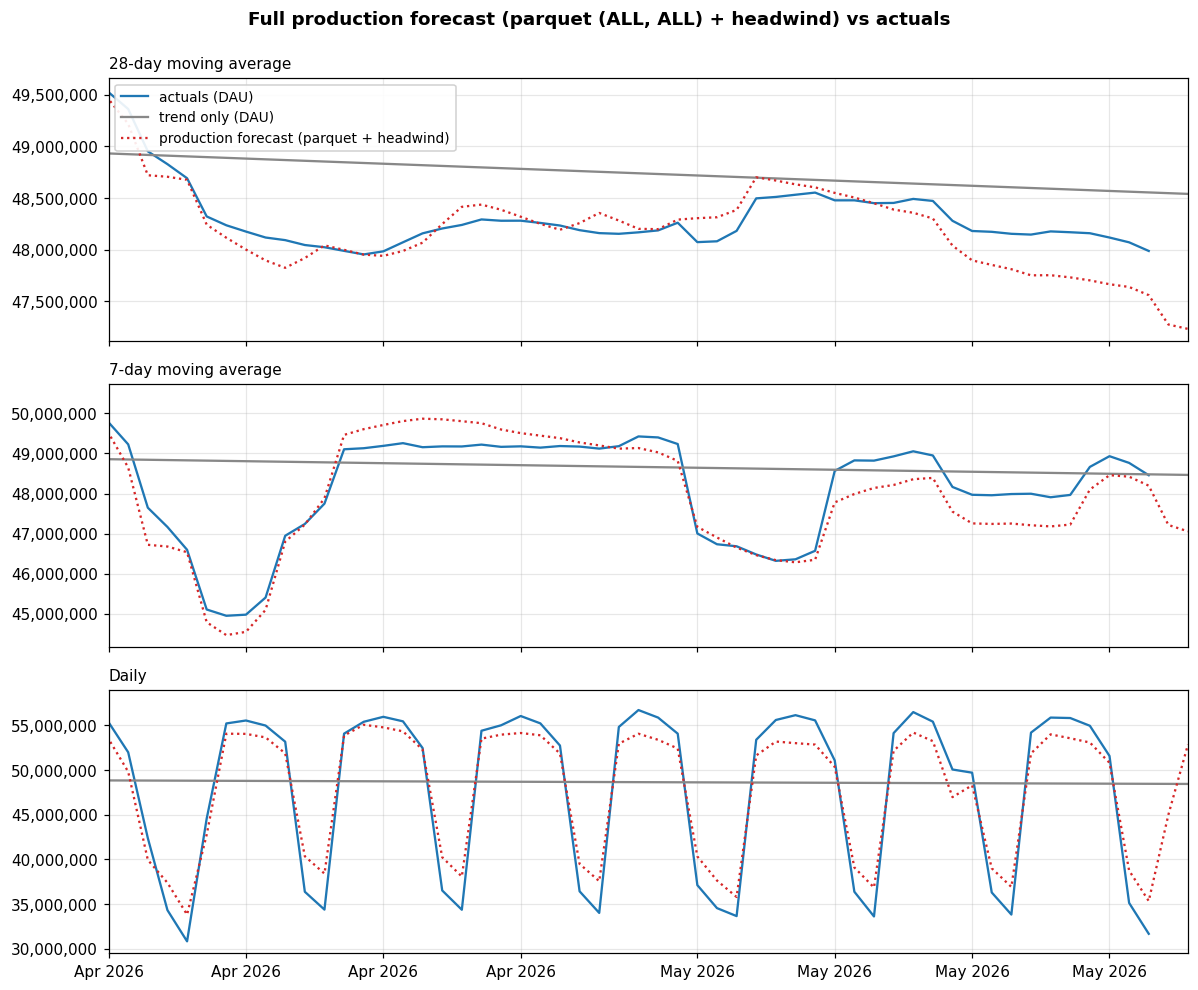

In [8]:
# [plot-yhat]
# Use the production parquet (ALL, ALL) row + headwind as the full forecast
# line — this is exactly what the composite CSV and the leadership chart show.
show_component(
    title='Full production forecast (parquet (ALL, ALL) + headwind) vs actuals',
    actual=actuals,
    trend_dau=components['dau_trend'],
    prediction_dau=production_forecast_with_headwind,
    prediction_label='production forecast (parquet + headwind)',
    blend_at_forecast_start=True,
)


## 2. Trend

Prophet's logistic-then-linear-with-log-transform trend, back-transformed to DAU. This is the slowest-moving component — the one that determines whether the post-FORECAST period is mis-fit at the level (rather than the seasonal-shape) level. If actuals' 28d MA persistently sits above this line in the post-FORECAST regime, the trend is the source of the gap.

No second prediction line here — there's nothing to add on top of trend yet.

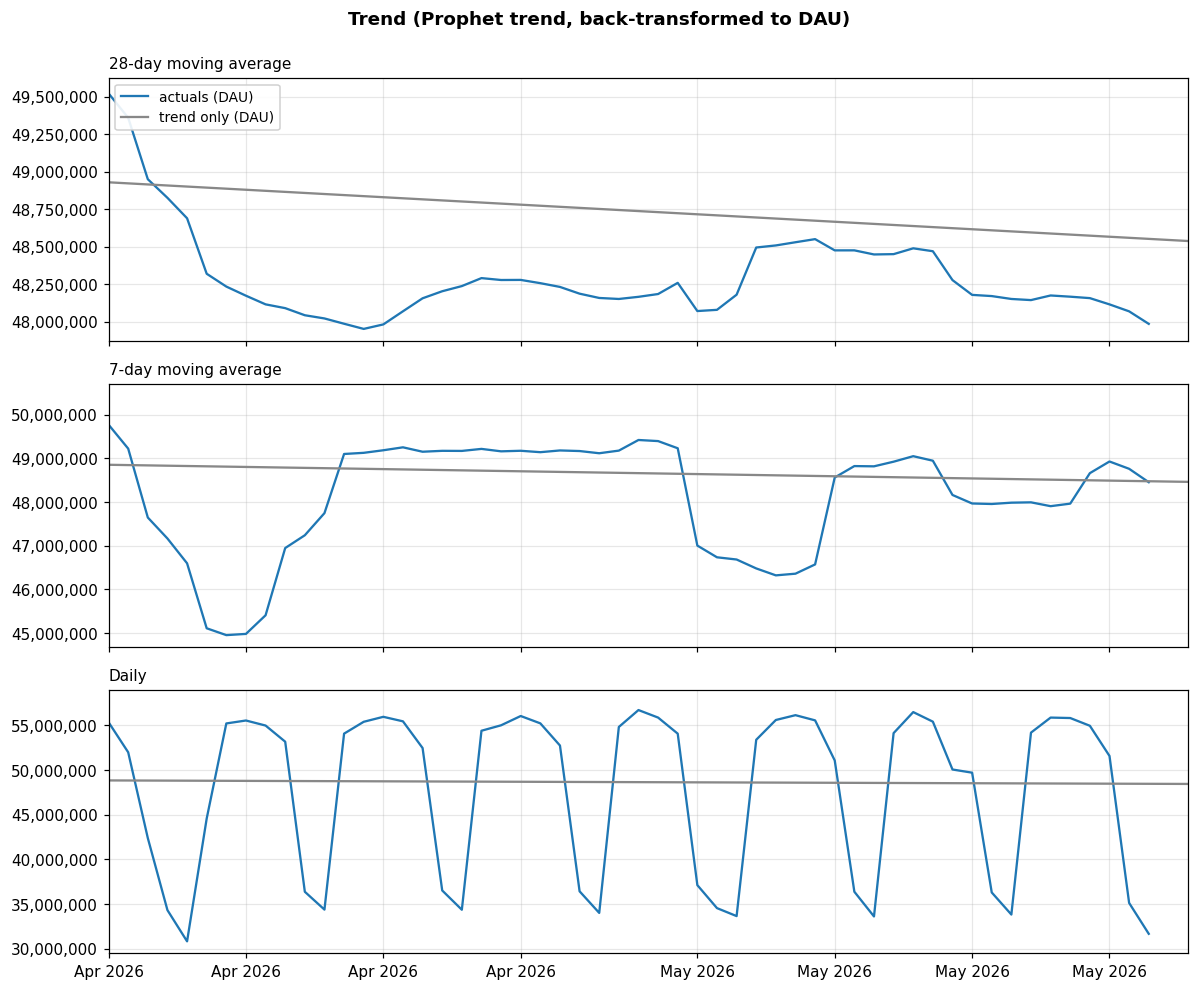

In [9]:
# [plot-trend]
show_component(
    title='Trend (Prophet trend, back-transformed to DAU)',
    actual=actuals,
    trend_dau=components['dau_trend'],
)

## 3. Yearly seasonality

Prophet's yearly seasonal factor (multiplicative on the log-trend), back-transformed and added on top of trend. The gap between the trend-only line and the trend+yearly line is the **isolated DAU contribution of yearly**. The gap between actuals and trend+yearly is everything yearly fails to capture (weekly oscillation, holidays, residual).

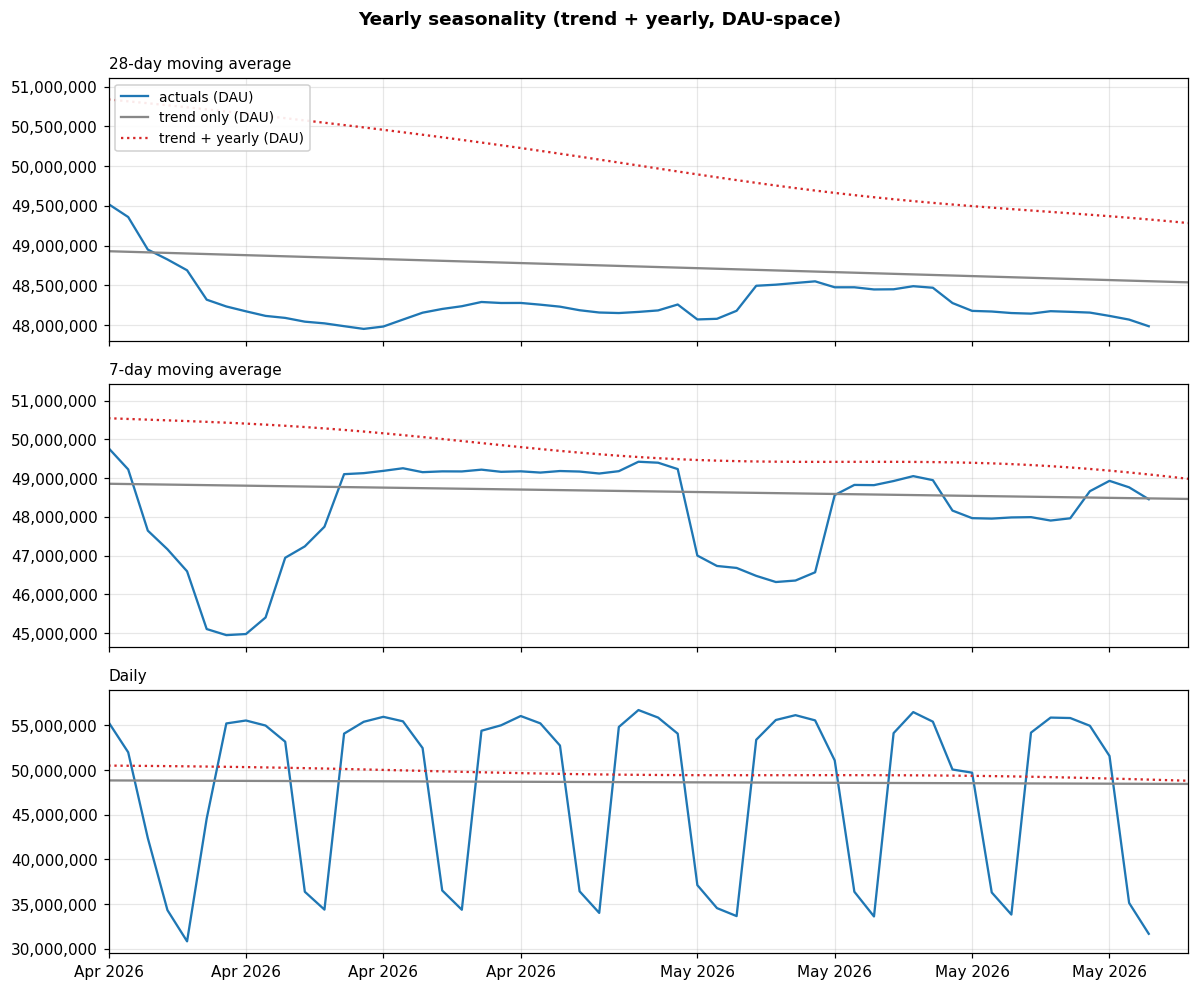

In [10]:
# [plot-yearly]
if 'dau_trend_plus_yearly' in components:
    show_component(
        title='Yearly seasonality (trend + yearly, DAU-space)',
        actual=actuals,
        trend_dau=components['dau_trend'],
        prediction_dau=components['dau_trend_plus_yearly'],
        prediction_label='trend + yearly (DAU)',
    )
else:
    print('Yearly seasonality not enabled for this fit '
          '(desktop_forecast_model only enables yearly when len(history) > 2yr and p50/p10 < 5).')

## 4. Weekly seasonality

Prophet's weekly seasonal factor. Plotted the same way as yearly. Note that 28d and 7d moving averages will substantially attenuate the weekly oscillation — the **Daily** pane is where this component reads cleanly.

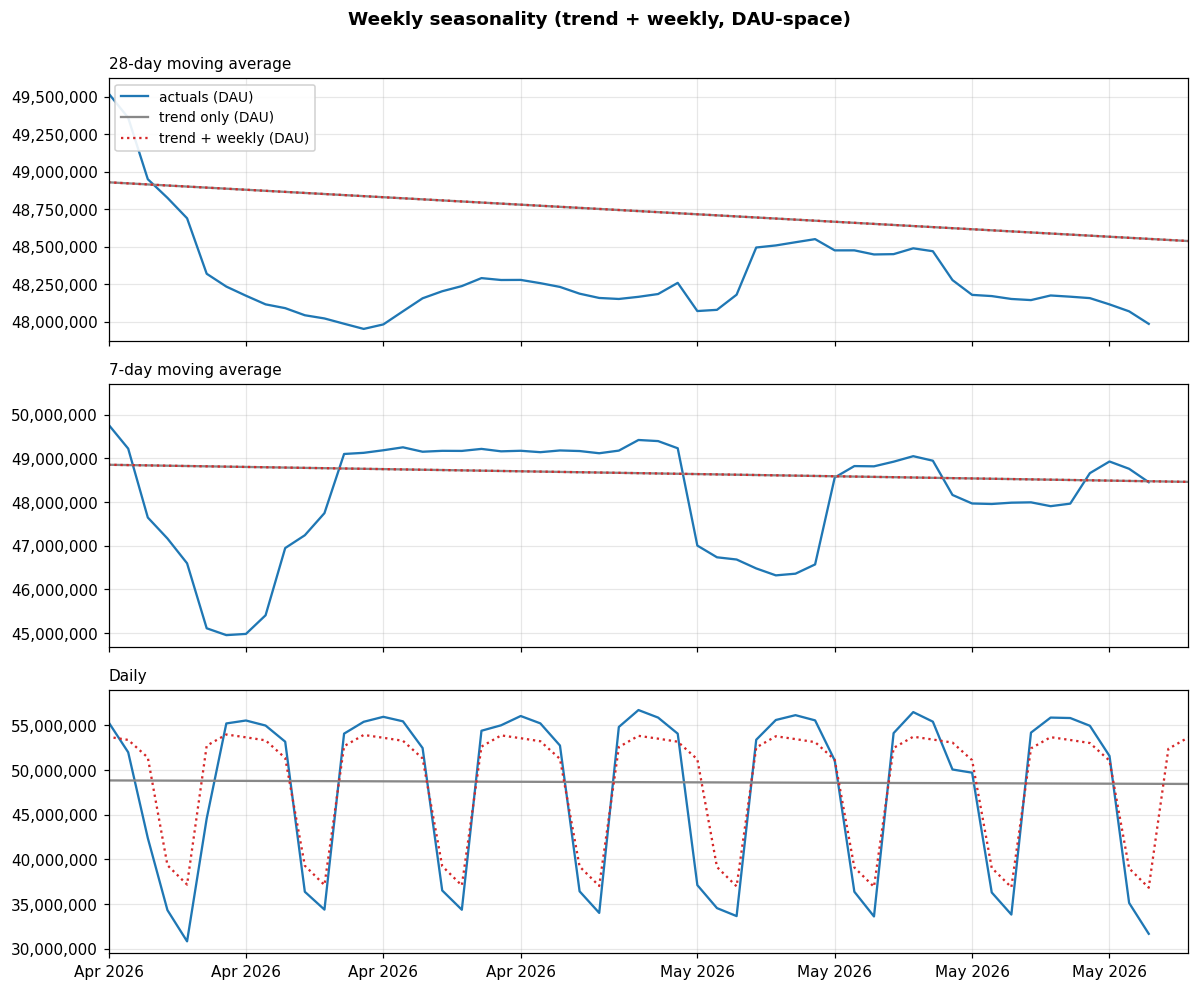

In [11]:
# [plot-weekly]
if 'dau_trend_plus_weekly' in components:
    show_component(
        title='Weekly seasonality (trend + weekly, DAU-space)',
        actual=actuals,
        trend_dau=components['dau_trend'],
        prediction_dau=components['dau_trend_plus_weekly'],
        prediction_label='trend + weekly (DAU)',
    )
else:
    print('Weekly seasonality column not found in Prophet predict output.')

## 5. Holidays — mozaic `holiday_smart`

Mozaic's holiday-detrending layer. Historical impacts (`historical_holiday_impacts`) are subtracted from `y` before Prophet sees it; forecasted impacts (`forecasted_holiday_impacts`) are added back to the reconciled forecast. The series is in DAU-space and additive.

The "prediction" line here is `trend + holiday_smart` — adding the holiday term directly to trend (Prophet's seasonal terms intentionally omitted) isolates the holiday signature against actuals.

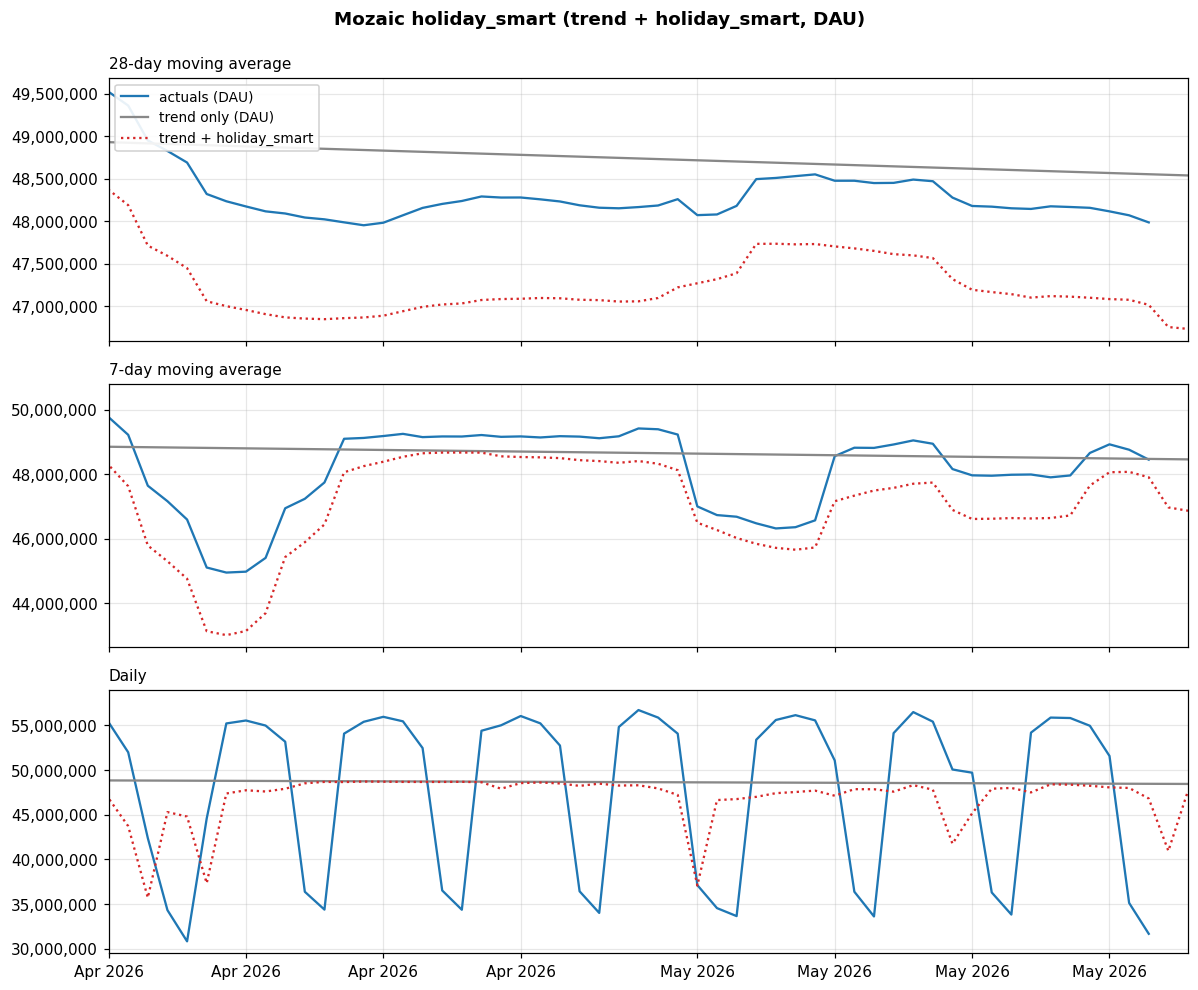

In [12]:
# [plot-holiday-smart]
trend_plus_hs = components['dau_trend'].add(holiday_smart, fill_value=0)
show_component(
    title='Mozaic holiday_smart (trend + holiday_smart, DAU)',
    actual=actuals,
    trend_dau=components['dau_trend'],
    prediction_dau=trend_plus_hs,
    prediction_label='trend + holiday_smart',
)

## 6. Prophet internal holidays — *not used in this fit*

`mozaic.models.desktop_forecast_model` does not pass `holidays=` to Prophet and does not call `add_country_holidays`. The training input is `holiday_detrended_historical_data` (see `mozaic/core.py:74-80`), which already has mozaic's `historical_holiday_impacts` subtracted out. So Prophet's `predict()` output will not have a `holidays` column at all (verified below).

**Conclusion.** Mozaic's `holiday_smart` (§5 above) is the only holiday term in the production forecast. There is no Prophet-internal holiday line to plot.

In [13]:
# [verify-no-prophet-holidays]
prophet_cols = list(prophet_predict.columns)
has_holiday_col = 'holidays' in prophet_cols
print(f'Prophet predict output columns: {prophet_cols}')
print(f"'holidays' column present? {has_holiday_col}")
if has_holiday_col:
    nz = (prophet_predict['holidays'].abs() > 1e-9).sum()
    print(f"  non-zero days: {nz:,} (will plot if > 0)")
    if nz > 0:
        show_component(
            title='Prophet internal holidays (unexpected for this fit)',
            actual=actuals,
            trend_dau=components['dau_trend'],
            prediction_dau=components['dau_trend'] + prophet_predict['holidays'],
            prediction_label='trend + prophet holidays',
        )

Prophet predict output columns: ['trend', 'cap', 'floor', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']
'holidays' column present? False


## 7. Cumulative buildup

Layered view: each plot adds one more component to the prediction line. Read top-to-bottom to see how much each component closes the gap to actuals.

1. **trend** alone
2. **trend + yearly**
3. **trend + yearly + weekly** (= Prophet `yhat`)
4. **trend + yearly + weekly + holiday_smart** (= full forecast)

This is the same information as §1–§5 reorganized; the goal is to see the cumulative improvement in fit rather than the isolated contribution of each component.

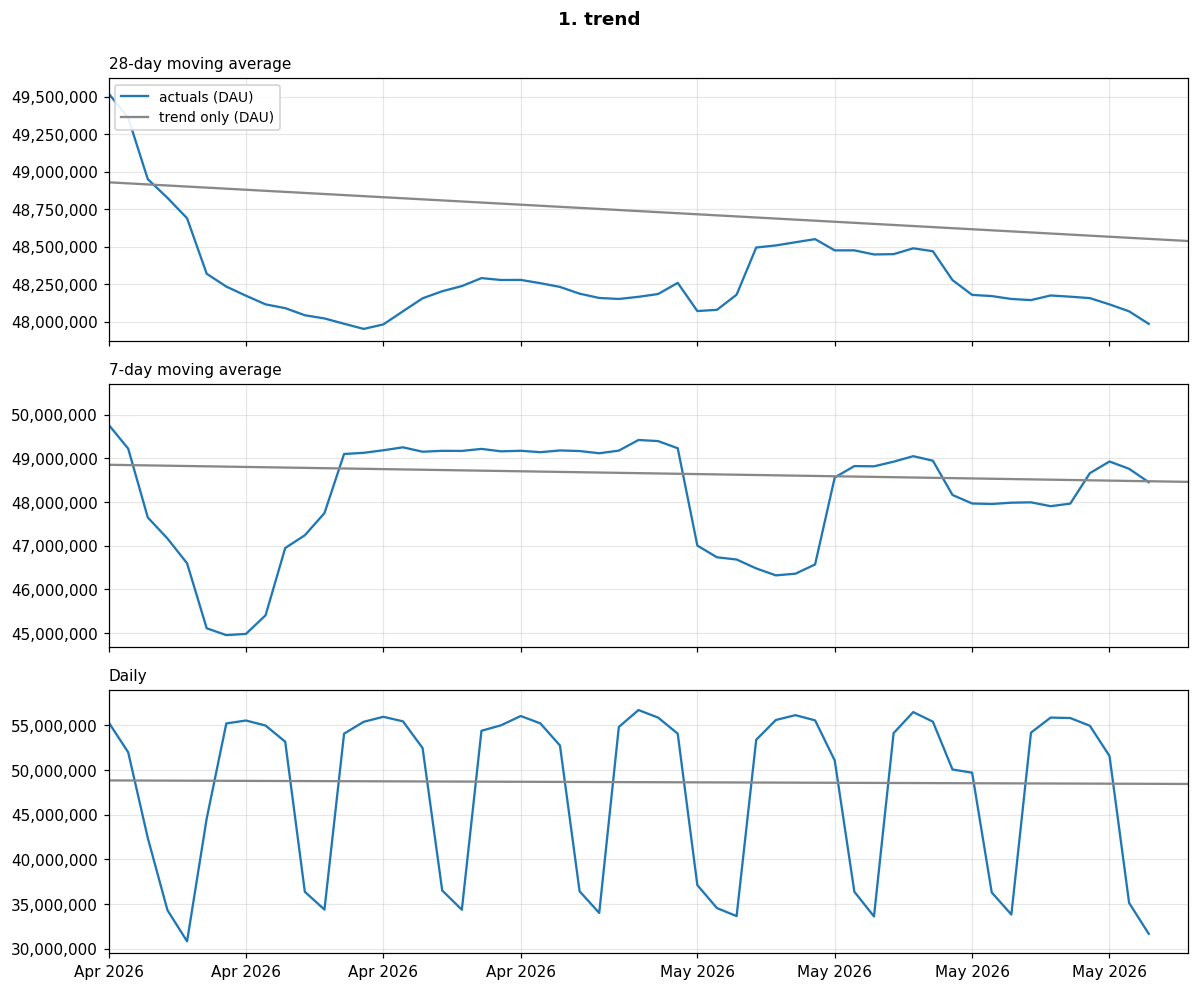

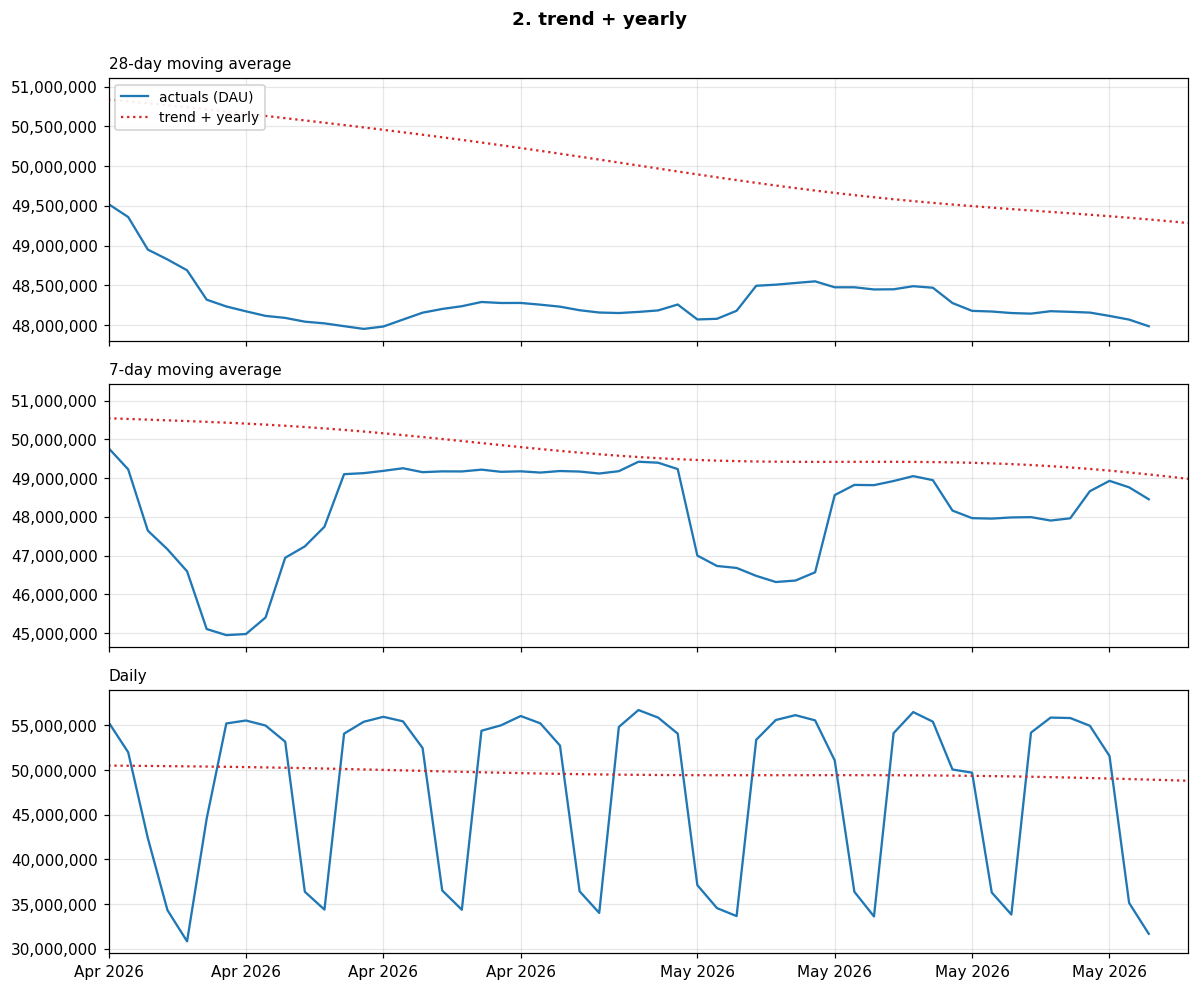

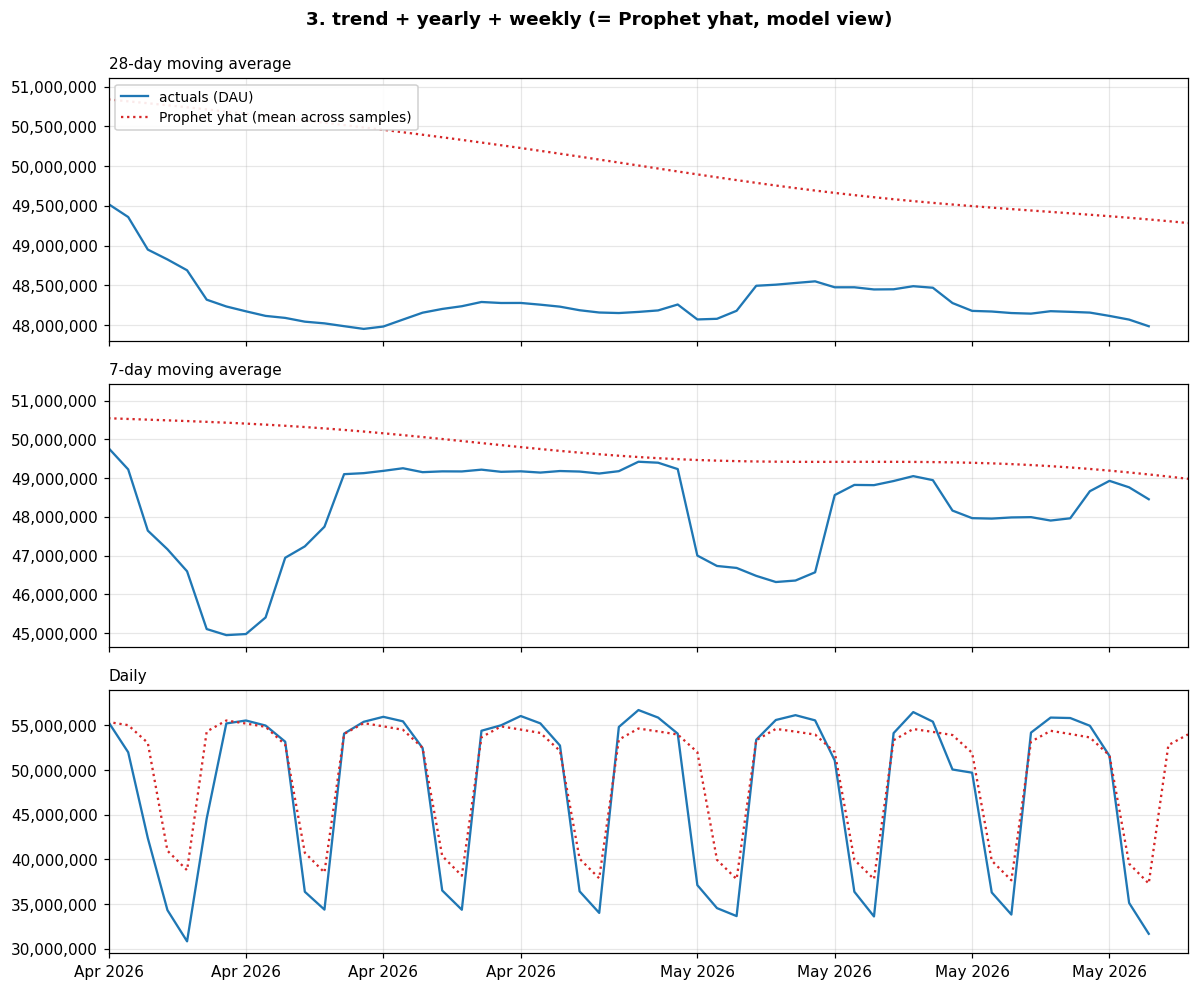

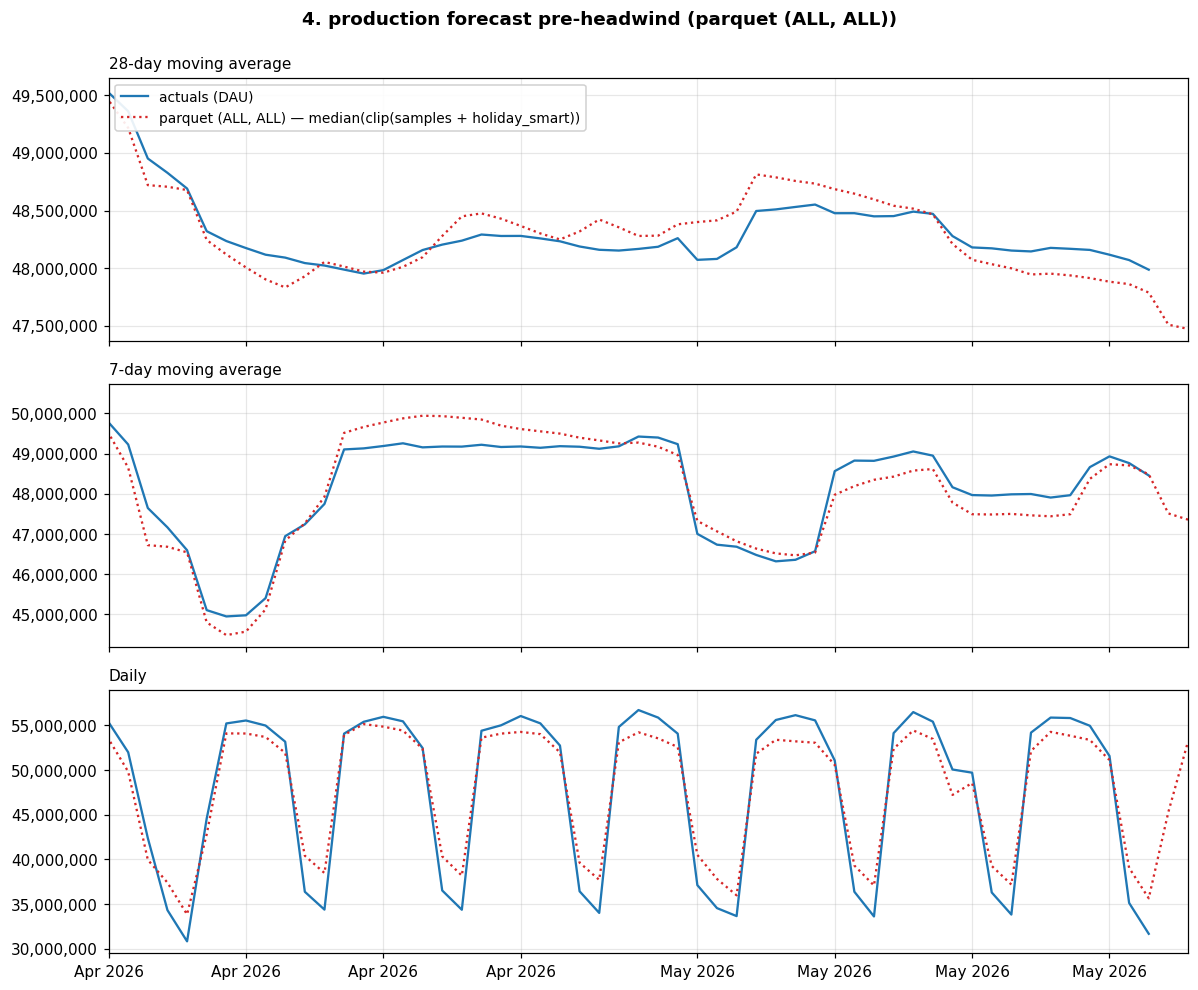

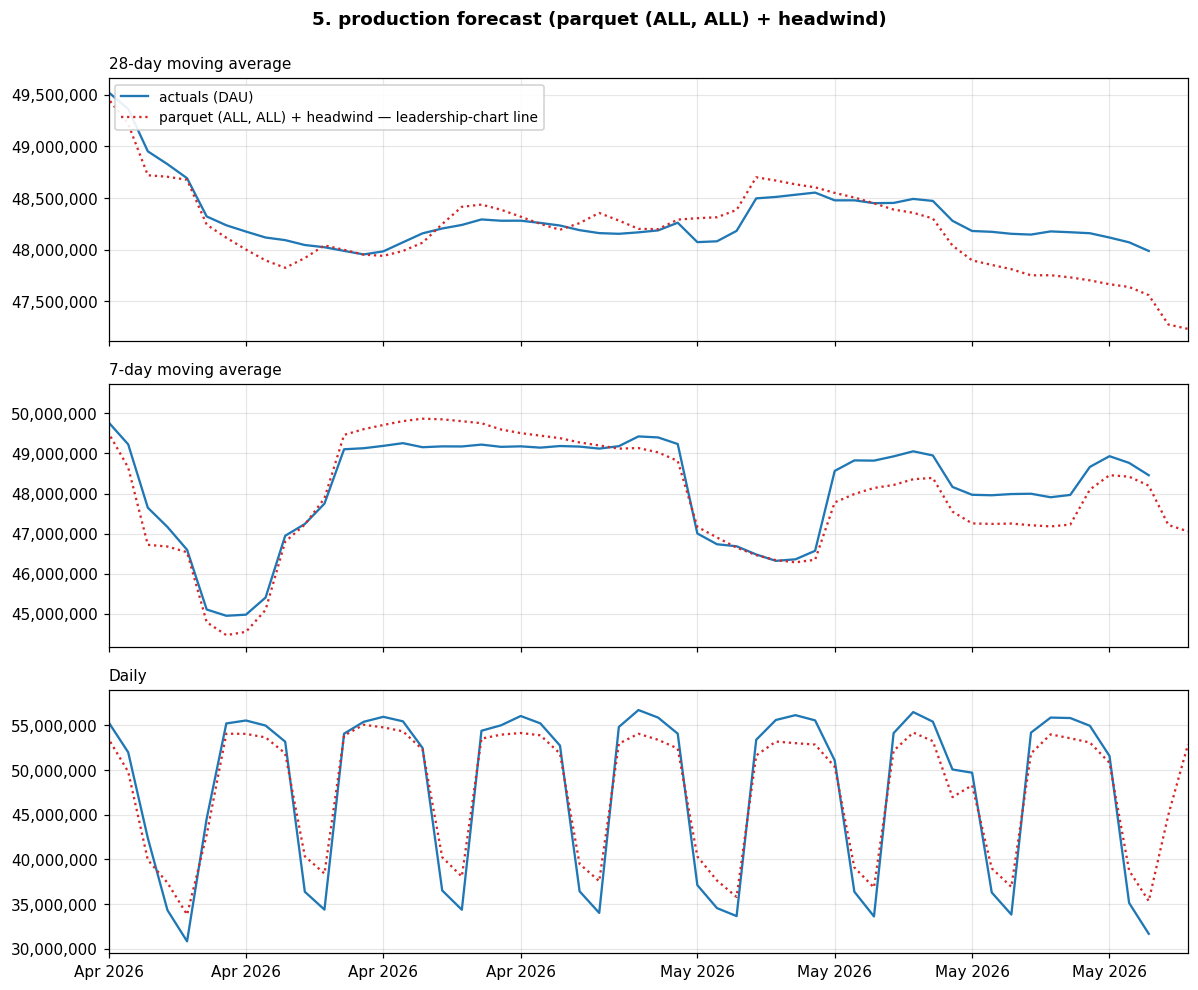

In [14]:
# [cumulative-layers]
# Build the cumulative buildup. Layers 1–3 use the model decomposition from
# Prophet's predict() output (the only way to see components individually).
# Layers 4 and 5 switch to the production parquet (ALL, ALL) row, which is
# what gets written to disk and consumed downstream — `median(clip(samples +
# holiday_smart))` rather than `mean(samples) + median(holiday_smart)`. The
# layer-3 → layer-4 delta therefore includes (a) the holiday_smart addition
# AND (b) the mean→median sample shift AND (c) clipping at zero. For most
# days (a) dominates by orders of magnitude.
if uses_log:
    dau_trend_plus_yw = np.exp(
        components['trend'] * (1.0 + components['yearly'] + components['weekly'])
    ) - 1.0
else:
    dau_trend_plus_yw = components['dau_yhat']  # additive: yhat = trend + yearly + weekly

cumulative_layers = [
    # (title, prediction, label, blend, show_trend_line)
    # show_trend_line is True only when trend is the focus (layer 1); the
    # remaining layers focus on what's been added on top of trend, so the
    # trend reference line is removed to reduce visual noise.
    ('1. trend', None, None, False, True),
    ('2. trend + yearly', components['dau_trend_plus_yearly'], 'trend + yearly', False, False),
    ('3. trend + yearly + weekly (= Prophet yhat, model view)', dau_trend_plus_yw,
     'Prophet yhat (mean across samples)', False, False),
    ('4. production forecast pre-headwind (parquet (ALL, ALL))', production_forecast,
     'parquet (ALL, ALL) — median(clip(samples + holiday_smart))', True, False),
    ('5. production forecast (parquet (ALL, ALL) + headwind)', production_forecast_with_headwind,
     'parquet (ALL, ALL) + headwind — leadership-chart line', True, False),
]
for title, pred, label, blend, show_trend in cumulative_layers:
    show_component(
        title=title,
        actual=actuals,
        trend_dau=components['dau_trend'] if show_trend else None,
        prediction_dau=pred,
        prediction_label=label,
        blend_at_forecast_start=blend,
    )


## 8. Actuals minus holiday effects vs Prophet yhat

Prophet was fit on `holiday_detrended_historical_data` — i.e., raw DAU with mozaic's `holiday_smart` already subtracted out. The cleanest test of *Prophet's* fit alone (independent of holiday allocation) is therefore actuals minus `holiday_smart` versus Prophet's `yhat`.

Note on sign: `holiday_smart` is non-positive (holidays only reduce desktop DAU), so subtracting it *adds back* the suppressed DAU. On a Christmas Day with raw actuals at 30M and holiday_smart at −10M, the de-holidayed actual is 40M — what DAU would have been without the holiday.

If this line diverges from `yhat` in the post-FORECAST regime, the gap is a Prophet fit problem (trend + seasonality) rather than a holiday-allocation problem.

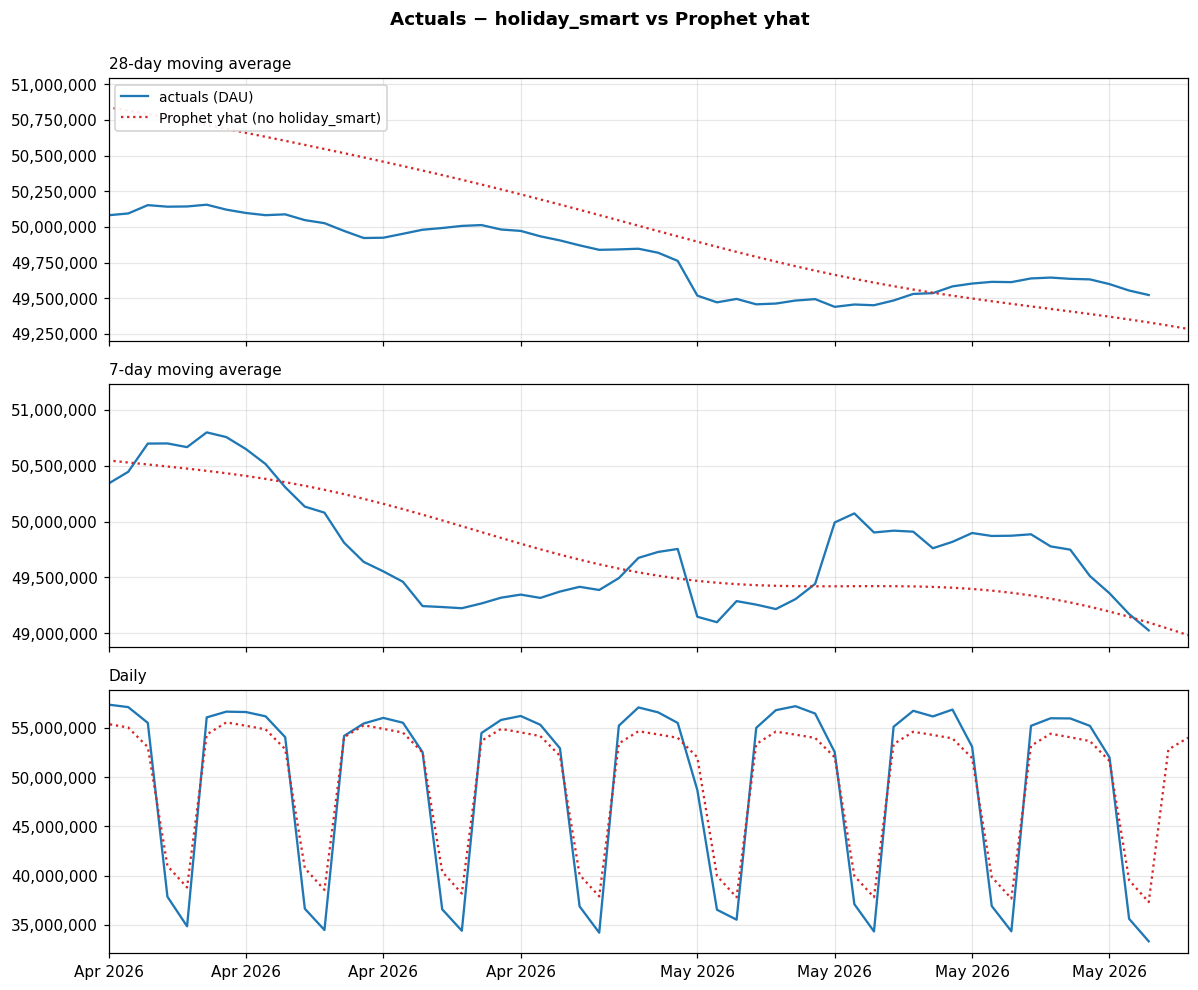

In [15]:
# [plot-actuals-deholiday]
actuals_deholiday = actuals.subtract(holiday_smart.reindex(actuals.index), fill_value=0)
show_component(
    title='Actuals − holiday_smart vs Prophet yhat',
    actual=actuals_deholiday,
    trend_dau=None,
    prediction_dau=components['dau_yhat'],
    prediction_label='Prophet yhat (no holiday_smart)',
)


## 9. All fit components on one axis

Each component drawn as its own line so you can see relative scale and timing in one picture. Trend dominates the absolute level (35M–45M DAU range) and lives on its own y-axis on the left; the other four components — yearly seasonality, combined weekly seasonality, mozaic `holiday_smart`, and the headwind ramp — all live on the right axis as DAU deltas (centered roughly around 0 or below).

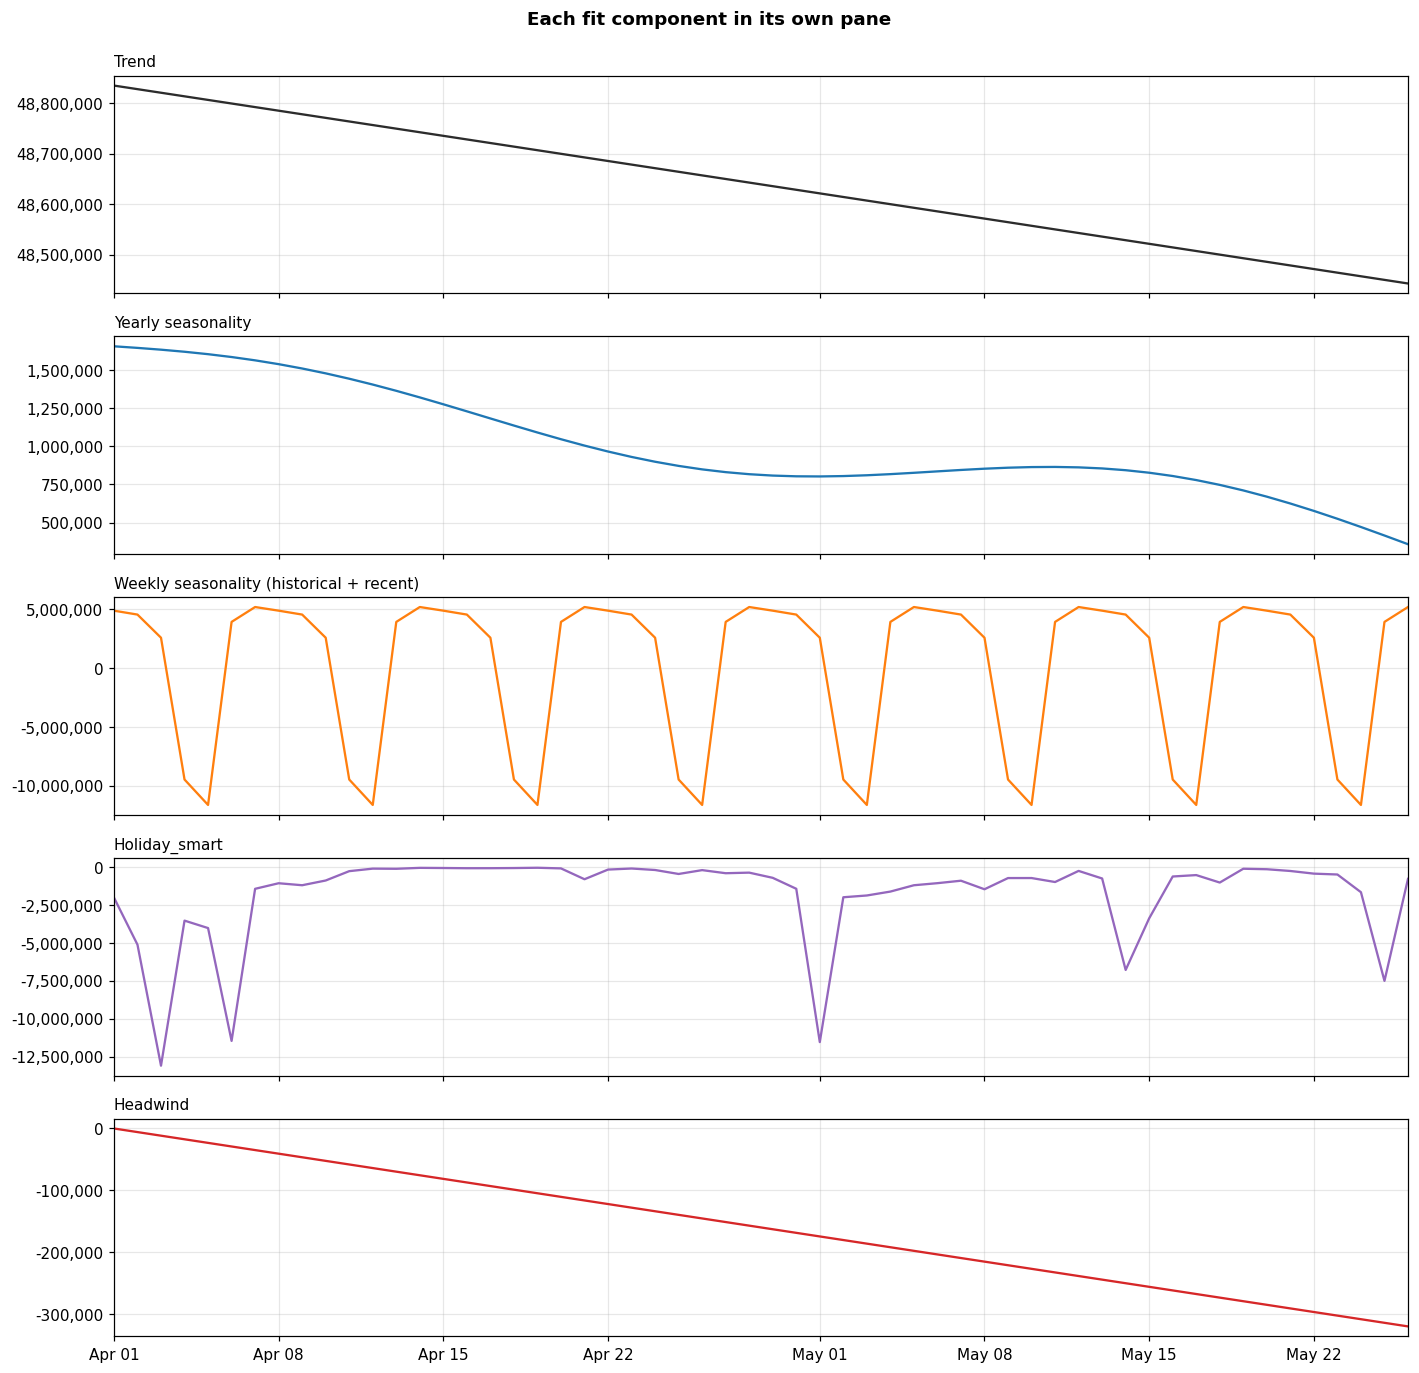

In [16]:
# [plot-components-overlay]
# Five stacked panes — one per fit component — each with its own y-axis so the
# component's structure reads cleanly regardless of magnitude.
component_panes = [
    ('Trend',                                          components['dau_trend'],   '#2c2c2c'),
    ('Yearly seasonality',                             components['yearly'],      '#1f77b4'),
    ('Weekly seasonality (historical + recent)',       components['weekly'],      '#ff7f0e'),
    ('Holiday_smart',                                  holiday_smart,             '#9467bd'),
    ('Headwind',                                       headwind_daily,            '#d62728'),
]

def _slice(s):
    return s.loc[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]

# Interactive plotly chart
fig = make_subplots(
    rows=len(component_panes), cols=1, shared_xaxes=True,
    subplot_titles=[p[0] for p in component_panes],
    vertical_spacing=0.04,
)
for i, (name, series, color) in enumerate(component_panes, start=1):
    sub = _slice(series)
    fig.add_trace(
        go.Scatter(x=sub.index, y=sub.values, mode='lines',
                   line=dict(color=color, width=1.5), name=name, showlegend=False),
        row=i, col=1,
    )
    fig.add_vline(x=FORECAST_START, line=dict(color='gray', width=1, dash='dash'),
                  row=i, col=1)
fig.update_layout(
    title='Each fit component in its own pane',
    height=220 * len(component_panes),
    margin=dict(t=70, l=80, r=30, b=40),
)
fig.update_yaxes(tickformat=',.0f')
fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END])
fig.show()

# Static matplotlib mirror
fig_m, axes = plt.subplots(
    len(component_panes), 1, figsize=(13, 2.5 * len(component_panes)), sharex=True,
)
for ax, (name, series, color) in zip(axes, component_panes):
    sub = _slice(series)
    ax.plot(sub.index, sub.values, color=color, linewidth=1.5)
    ax.axvline(FORECAST_START, color='gray', linestyle='--', linewidth=1)
    ax.set_title(name, loc='left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].set_xlim(DISPLAY_START, DISPLAY_END)
fig_m.suptitle('Each fit component in its own pane', fontweight='bold', y=0.995)
fig_m.tight_layout()
plt.show()
plt.close(fig_m)


## 10. Seasonal cycles in isolation

Each Prophet seasonality plotted against its natural period — day-of-year for yearly, day-of-week for weekly — so the underlying shape reads cleanly without any time-axis or trend confound.

For weekly, the april-branch model fits **two** seasonalities — `weekly_historical` (active for training rows older than ~13 weeks before forecast start) and `weekly_recent` (active for the last 13 weeks + the forecast). Both are plotted on the same axis so you can see whether the recent-window weekly pattern differs from the long-run weekly pattern. If they diverge meaningfully, the model is capturing a weekly-regime shift.

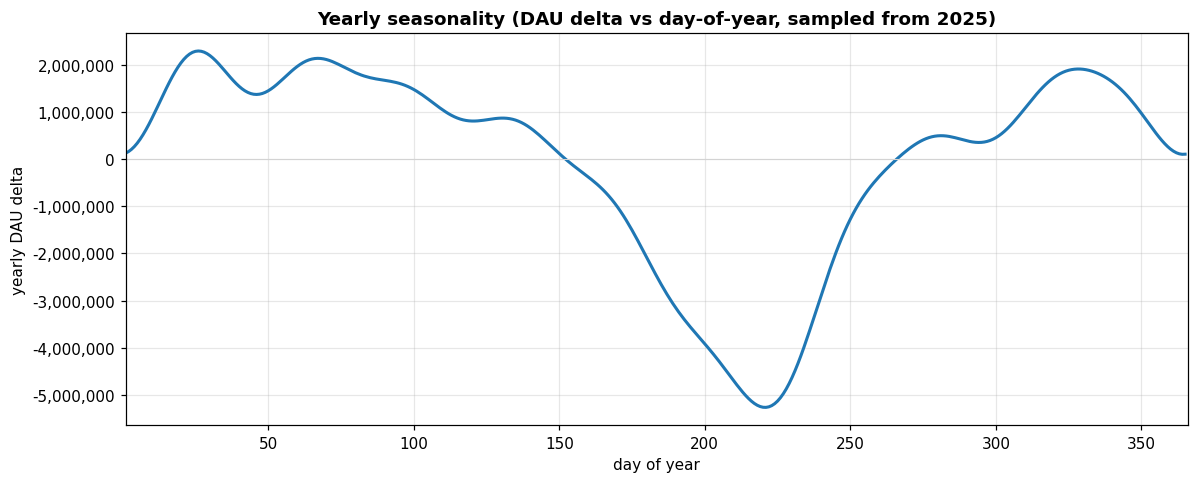

In [17]:
# [plot-yearly-cycle]
# Take one full calendar year of the yearly component and plot it vs day-of-year.
# Pick 2025 because it's a clean full year inside the training window.
year_sub = components.loc['2025-01-01':'2025-12-31', 'yearly'].copy()
year_sub.index = year_sub.index.dayofyear

fig = go.Figure()
fig.add_trace(go.Scatter(x=year_sub.index, y=year_sub.values, mode='lines',
                          line=dict(color='#1f77b4', width=2), name='yearly'))
fig.add_hline(y=0, line=dict(color='lightgray', width=1))
fig.update_layout(
    title='Yearly seasonality (DAU delta vs day-of-year, sampled from 2025)',
    height=420, margin=dict(t=60, l=70, r=30, b=40),
    xaxis=dict(title='day of year', range=[1, 366]),
    yaxis=dict(title='yearly DAU delta', tickformat=',.0f', zeroline=True),
)
fig.show()

fig_m, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(year_sub.index, year_sub.values, color='#1f77b4', linewidth=2)
ax.axhline(0, color='lightgray', linewidth=0.7)
ax.set_xlabel('day of year')
ax.set_ylabel('yearly DAU delta')
ax.set_xlim(1, 366)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Yearly seasonality (DAU delta vs day-of-year, sampled from 2025)', fontweight='bold')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

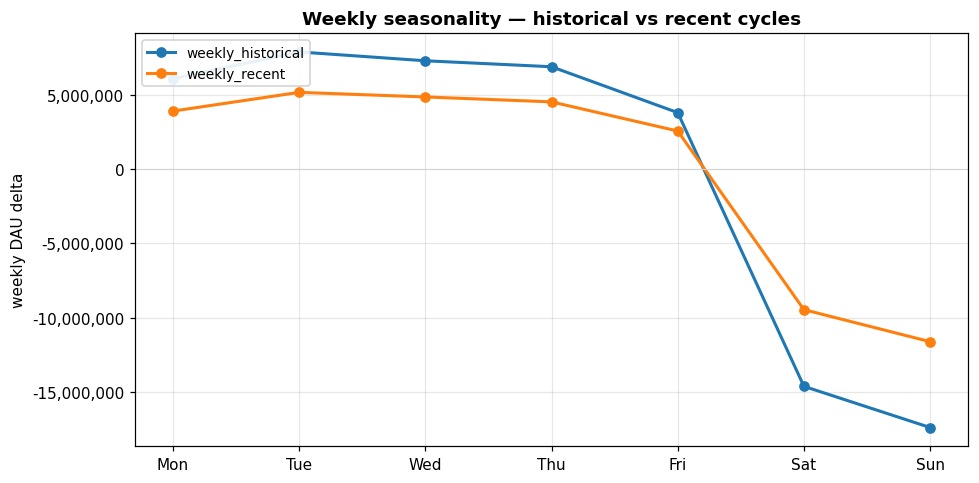

In [18]:
# [plot-weekly-cycle]
# The model has two weekly seasonalities (historical vs recent). Extract each on
# its own — for each, pick a week where that condition was active and read off
# the day-of-week pattern.
week_view = prophet_predict[['weekly_historical', 'weekly_recent']].copy()
week_view['day_of_week'] = week_view.index.dayofweek  # 0 = Monday

# weekly_historical is nonzero only for rows where is_historical=True;
# weekly_recent is nonzero only where is_recent=True. Group by dow and take mean
# across nonzero rows so the cycle reads cleanly.
hist_nz = week_view[week_view['weekly_historical'].abs() > 1e-9]
recent_nz = week_view[week_view['weekly_recent'].abs() > 1e-9]
hist_by_dow = hist_nz.groupby('day_of_week')['weekly_historical'].mean()
recent_by_dow = recent_nz.groupby('day_of_week')['weekly_recent'].mean()

DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig = go.Figure()
fig.add_trace(go.Scatter(x=DOW_LABELS, y=hist_by_dow.reindex(range(7)).values,
                          mode='lines+markers', name='weekly_historical',
                          line=dict(color='#1f77b4', width=2)))
fig.add_trace(go.Scatter(x=DOW_LABELS, y=recent_by_dow.reindex(range(7)).values,
                          mode='lines+markers', name='weekly_recent',
                          line=dict(color='#ff7f0e', width=2)))
fig.add_hline(y=0, line=dict(color='lightgray', width=1))
fig.update_layout(
    title='Weekly seasonality — historical vs recent cycles',
    height=420, margin=dict(t=60, l=70, r=30, b=40),
    yaxis=dict(title='weekly DAU delta', tickformat=',.0f', zeroline=True),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.show()

fig_m, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(DOW_LABELS, hist_by_dow.reindex(range(7)).values, 'o-', color='#1f77b4',
        linewidth=2, label='weekly_historical')
ax.plot(DOW_LABELS, recent_by_dow.reindex(range(7)).values, 'o-', color='#ff7f0e',
        linewidth=2, label='weekly_recent')
ax.axhline(0, color='lightgray', linewidth=0.7)
ax.set_ylabel('weekly DAU delta')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Weekly seasonality — historical vs recent cycles', fontweight='bold')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)


## 11. Why this differs from the leadership chart

My reconstruction in §1/§7 is built from the saved Prophet model via `predict()` + `holiday_smart` + headwind. The leadership-facing chart is built from the **production composite CSV** (`april_composite_forecast_28ma.adj-h.csv`) and the **raw parquet** (`mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet`'s `(ALL, ALL)` row). These three paths can diverge in three places:

1. **Mean vs median across samples.** My code uses Prophet's `yhat` (the mean across predictive samples). The parquet uses `median(samples + holiday_smart, clip(lower=0))` (the median, with holiday impact already added per-sample before clipping). For non-holiday days these are very close; on holiday days the clip-then-median path differs slightly from add-medians-without-clip.
2. **MA blending at the window edge.** The composite CSV's 28d MA at, say, April 5 is `mean(actuals_Mar9–Mar31 ∪ forecast_Apr1–Apr5)`. My chart's 28d MA at April 5 is `mean(prophet_fit_Mar9–Mar31 ∪ forecast_Apr1–Apr5)` — it blends Prophet's *in-sample fit values*, not real actuals. Prophet's fit is close to but not identical to actuals, so the MA values diverge for the first ~28 days of the display window.
3. **What's included.** The composite CSV is built by `april_composite_forecast.ipynb` from the raw parquet's `(ALL, ALL)` row plus a headwind ramp. No mobile, no Iran composition (we're looking at the `desktop_28ma_no_iran` column).

The cell below overlays my reconstruction with both production artifacts so you can see where they diverge.

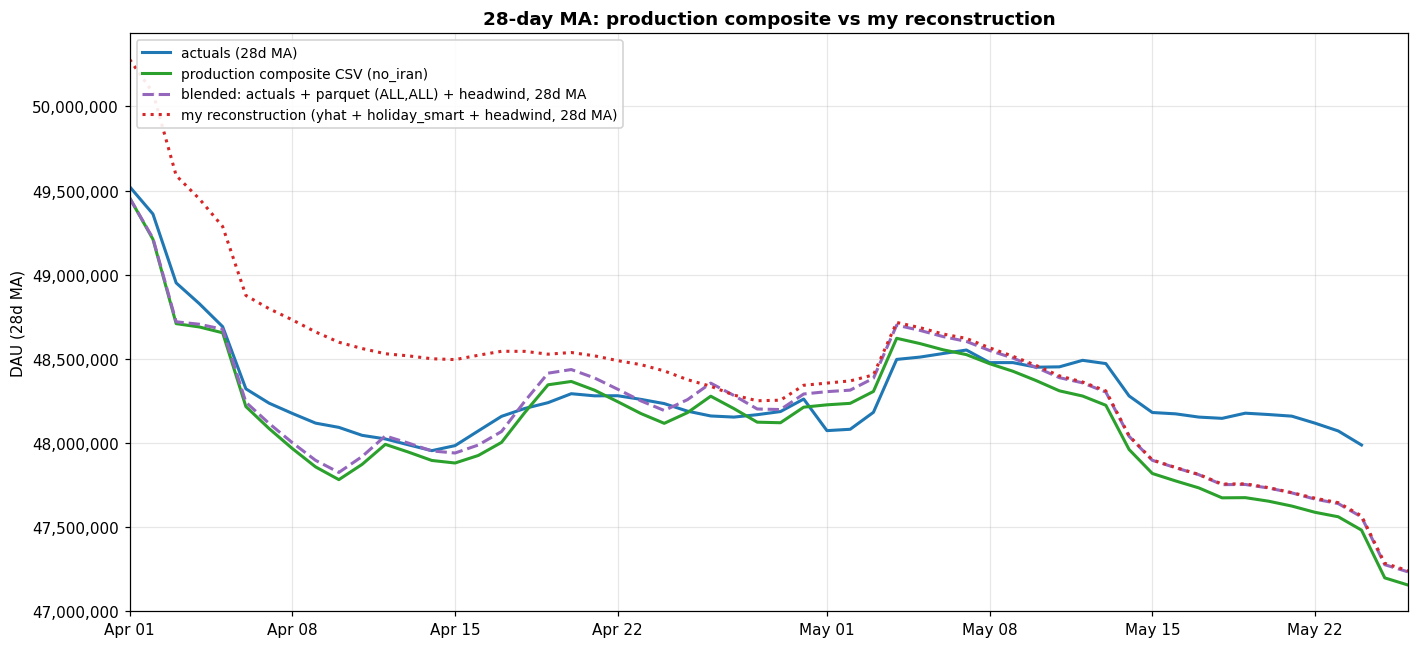

Endpoint comparison (last available value in each):
  actuals 28dMA                                           2026-05-24:   47,987,198
  production composite (no_iran)                          2026-05-26:   47,154,728
  blended (actuals + parquet + headwind, 28dMA)           2026-05-26:   47,233,105
  my reconstruction                                       2026-05-26:   47,239,829


In [19]:
# [diag-compare-production]
# Load production artifacts.
composite_csv = pd.read_csv('data-official/2026-04/april_composite_forecast_28ma.adj-h.csv')
composite_csv['date'] = pd.to_datetime(composite_csv['date'])
prod_composite = composite_csv.set_index('date')['desktop_28ma_no_iran'].sort_index()

prod_parquet = pd.read_parquet(
    'data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet'
)
prod_parquet['target_date'] = pd.to_datetime(prod_parquet['target_date'])
# Raw parquet has segment={"os":"ALL"} row at (country=ALL, os=ALL). That's the
# metric-mozaic's own forecast — pre-headwind, post-holiday_smart, sample-median.
prod_all_all = (
    prod_parquet[(prod_parquet['country'] == 'ALL') & (prod_parquet['segment'] == '{"os": "ALL"}')]
    .set_index('target_date')['dau'].sort_index()
)
# Add the headwind ramp (production composite producer adds it as a post-step).
prod_all_all_with_headwind = prod_all_all.add(headwind_daily.reindex(prod_all_all.index), fill_value=0)
prod_all_all_with_headwind_28ma = to_ma(prod_all_all_with_headwind, 28)

# My reconstruction.
full_pred_mine = (
    components['dau_yhat'].add(holiday_smart, fill_value=0).add(headwind_daily, fill_value=0)
)
full_pred_mine_28ma = to_ma(full_pred_mine, 28)

# Same 28d MA, computed by blending actuals (pre-FORECAST_START) and the parquet's
# daily forecast values (post-FORECAST_START) — i.e. what the composite producer does.
blended_daily = pd.concat([
    actuals.loc[actuals.index < FORECAST_START],
    prod_all_all_with_headwind.loc[prod_all_all_with_headwind.index >= FORECAST_START],
]).sort_index()
blended_daily = blended_daily[~blended_daily.index.duplicated(keep='last')]
blended_28ma = to_ma(blended_daily, 28)

# Plot all four 28d MAs.
fig = go.Figure()
for name, s, color, dash in [
    ('actuals (28d MA)', to_ma(actuals, 28), '#1f77b4', None),
    ('production composite CSV (no_iran)', prod_composite, '#2ca02c', None),
    ('blended: actuals + parquet (ALL,ALL) + headwind, 28d MA', blended_28ma, '#9467bd', 'dash'),
    ('my reconstruction (yhat + holiday_smart + headwind, 28d MA)', full_pred_mine_28ma, '#d62728', 'dot'),
]:
    sub = s.loc[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]
    fig.add_trace(go.Scatter(x=sub.index, y=sub.values, mode='lines', name=name,
                              line=dict(color=color, dash=dash, width=2)))
fig.add_vline(x=FORECAST_START, line=dict(color='gray', width=1, dash='dash'))
fig.update_layout(
    title='28-day MA: production composite vs my reconstruction',
    height=520, margin=dict(t=70, l=70, r=30, b=40),
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='right', x=1),
    yaxis=dict(title='DAU (28d MA)', tickformat=',.0f'),
)
fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END])
fig.show()

fig_m, ax = plt.subplots(figsize=(13, 6))
for name, s, color, ls in [
    ('actuals (28d MA)', to_ma(actuals, 28), '#1f77b4', '-'),
    ('production composite CSV (no_iran)', prod_composite, '#2ca02c', '-'),
    ('blended: actuals + parquet (ALL,ALL) + headwind, 28d MA', blended_28ma, '#9467bd', '--'),
    ('my reconstruction (yhat + holiday_smart + headwind, 28d MA)', full_pred_mine_28ma, '#d62728', ':'),
]:
    sub = s.loc[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]
    ax.plot(sub.index, sub.values, color=color, linewidth=2, linestyle=ls, label=name)
ax.axvline(FORECAST_START, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('DAU (28d MA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlim(DISPLAY_START, DISPLAY_END)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_title('28-day MA: production composite vs my reconstruction', fontweight='bold')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

# Print summary stats.
print('Endpoint comparison (last available value in each):')
for name, s in [('actuals 28dMA', to_ma(actuals, 28)),
                ('production composite (no_iran)', prod_composite),
                ('blended (actuals + parquet + headwind, 28dMA)', blended_28ma),
                ('my reconstruction', full_pred_mine_28ma)]:
    sub = s.loc[s.index <= DISPLAY_END].dropna()
    if len(sub):
        print(f'  {name:<55} {sub.index[-1].date()}: {sub.iloc[-1]:>12,.0f}')

## 12. Year-over-year — is the April→May dip historically grounded?

Prophet learned a yearly seasonality that has May notably lower than April. §8 showed actuals declining only mildly through May while Prophet's yhat declines steeply. To see whether Prophet's pattern is justified, the cells below pull the **holiday-detrended** April–May actuals for every available year (2020 → 2026) and overlay them on a common axis along with Prophet's in-sample / forecast yhat for the same windows.

**Why holiday-detrended?** Calendar holidays (Easter, Memorial Day, etc.) shift by 5–30 days year to year and would create spurious year-vs-year differences in a raw comparison. The holiday-detrended actuals = `raw_historical_data − holiday_smart` — exactly the series Prophet was fit on (per `mozaic/core.py:74-80`). Prophet's yhat has no internal holiday term either, so this comparison is apples-to-apples.

**Training data scope.** Legacy-desktop DAU is queried from `2020-01-01` onward (`mozaic_daily/queries.py:349`), so the metric mozaic's `historical_dates` covers 7 April–May windows: 2020 through 2026. **2020 and 2021 are COVID-anomalous** (shutdown spike, work-from-home shift); they're plotted in gray so they're identifiable but don't visually compete with normal years. Prophet's yearly seasonality was fit on all of these jointly, so the 2020/2021 windows are part of what taught the model the pattern.

**How to read.** Each year's 28d MA is normalized to its own April 1 value = 100, so we compare *shape* (the % change from April through May) not absolute level. If Prophet's pattern matches historical actuals, the bottom curves should track the top. If Prophet's curves dip more steeply than actuals across all (or most) years, the yearly seasonality is over-amplified.


In [20]:
# [yoy-build-series]
# Unified raw actuals: mozaic's raw_historical_data covers 2020-01-01 →
# 2026-04-06; the BQ actuals query covers 2026-03-04 onwards. Stitch them so
# we get one continuous DAU series from training start through today.
mozaic_actuals = pd.Series(
    np.asarray(metric_mozaic.raw_historical_data).reshape(-1),
    index=pd.DatetimeIndex(metric_mozaic.historical_dates),
    name='dau',
).sort_index()
cutoff = actuals.index.min()
unified_actuals = pd.concat([
    mozaic_actuals.loc[mozaic_actuals.index < cutoff],
    actuals,
]).sort_index()
unified_actuals = unified_actuals[~unified_actuals.index.duplicated(keep='last')]

# Holiday-detrended actuals: subtract mozaic's holiday_smart impacts. This is
# exactly the series Prophet was fit on (`holiday_detrended_historical_data`)
# for historical dates, extended forward by subtracting the same holiday_smart
# from the post-training BQ actuals. Apples-to-apples with Prophet yhat, which
# has no internal holiday term.
unified_detrended = unified_actuals.subtract(
    holiday_smart.reindex(unified_actuals.index, fill_value=0)
)
print(f'Unified actuals:           {unified_actuals.index.min().date()} → {unified_actuals.index.max().date()}, {len(unified_actuals):,} dates')
print(f'Unified detrended actuals: {unified_detrended.index.min().date()} → {unified_detrended.index.max().date()}, {len(unified_detrended):,} dates')

# Legacy desktop DAU queries from 2020-01-01, so we have 7 years of April–May
# windows. 2020 and 2021 are COVID-anomalous; they're shown grayed so the user
# can spot them in the chart without giving them visual weight equal to normal
# years.
YEARS = [2020, 2021, 2022, 2023, 2024, 2025, 2026]
YEAR_COLORS = {
    2020: '#bbbbbb',   # COVID year — gray
    2021: '#777777',   # COVID-tail year — darker gray
    2022: '#1f77b4',   # blue
    2023: '#2ca02c',   # green
    2024: '#ff7f0e',   # orange
    2025: '#9467bd',   # purple
    2026: '#d62728',   # red — current forecast year (highlight)
}


def year_slice_28ma_normalized(series, year, anchor_month=4, anchor_day=1, end_month=5, end_day=31):
    """28d MA of `series` for [anchor, end] within `year`, normalized so that the
    28d MA value at the anchor date is 100."""
    warmup = pd.Timestamp(year, anchor_month, anchor_day) - pd.Timedelta(days=28)
    end = pd.Timestamp(year, end_month, end_day)
    sub = series.loc[(series.index >= warmup) & (series.index <= end)]
    if len(sub) < 28:
        return pd.Series(dtype=float)
    ma = sub.rolling(28).mean().dropna()
    ma = ma.loc[ma.index >= pd.Timestamp(year, anchor_month, anchor_day)]
    if len(ma) == 0:
        return pd.Series(dtype=float)
    return ma / ma.iloc[0] * 100.0


def align_to_common_year(s, common_year=2024):
    """Remap a date-indexed series so the index uses `common_year` for every date,
    keeping month/day. (Apr–May has no Feb-29 so leap-year is a non-issue.)"""
    return pd.Series(
        s.values,
        index=s.index.map(lambda d: pd.Timestamp(common_year, d.month, d.day)),
    )


actuals_yoy = {
    y: align_to_common_year(year_slice_28ma_normalized(unified_detrended, y))
    for y in YEARS
}
yhat_yoy = {
    y: align_to_common_year(year_slice_28ma_normalized(components['dau_yhat'], y))
    for y in YEARS
}

print('\nSummary (% change from Apr 1 to May 31, 28d MA):')
print(f'  {"year":>4}   {"actuals (det.)":>18}   {"Prophet yhat":>16}')
for y in YEARS:
    a = actuals_yoy[y]
    h = yhat_yoy[y]
    a_str = f'{a.iloc[-1] - a.iloc[0]:+6.2f}%' if len(a) else '   (n/a)'
    h_str = f'{h.iloc[-1] - h.iloc[0]:+6.2f}%' if len(h) else '   (n/a)'
    print(f'  {y:>4}   {a_str:>18}   {h_str:>16}')


Unified actuals:           2020-01-01 → 2026-05-24, 2,336 dates
Unified detrended actuals: 2020-01-01 → 2026-05-24, 2,336 dates

Summary (% change from Apr 1 to May 31, 28d MA):
  year       actuals (det.)       Prophet yhat
  2020               +0.81%             -1.98%
  2021               -5.77%             -2.43%
  2022               -3.16%             -3.26%
  2023               -4.45%             -2.96%
  2024               -3.08%             -2.95%
  2025               -2.67%             -3.14%
  2026               -1.12%             -3.34%


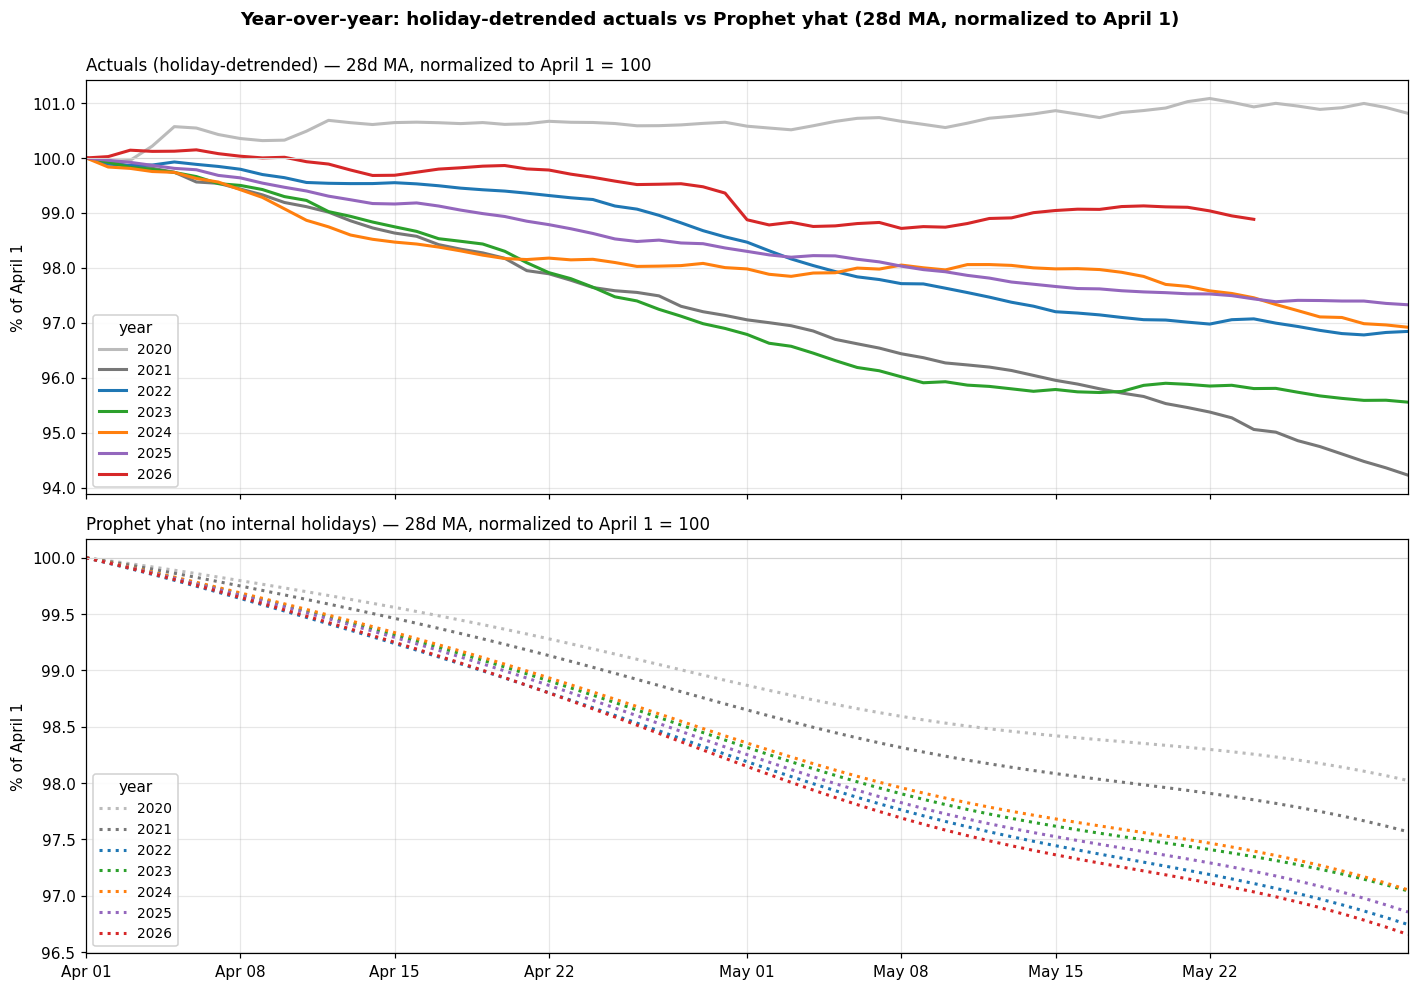

In [21]:
# [yoy-plot]
COMMON_X_START = pd.Timestamp(2024, 4, 1)
COMMON_X_END = pd.Timestamp(2024, 5, 31)

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    subplot_titles=(
        'Actuals (holiday-detrended) — 28d MA, normalized to April 1 = 100',
        'Prophet yhat (no internal holidays) — 28d MA, normalized to April 1 = 100',
    ),
    vertical_spacing=0.10,
)
for y in YEARS:
    s = actuals_yoy[y]
    if len(s):
        fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines', name=f'{y} actuals (det.)',
                                  line=dict(color=YEAR_COLORS[y], width=2),
                                  legendgroup=f'actuals-{y}'), row=1, col=1)
    s = yhat_yoy[y]
    if len(s):
        fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines', name=f'{y} yhat',
                                  line=dict(color=YEAR_COLORS[y], width=2, dash='dot'),
                                  legendgroup=f'yhat-{y}'), row=2, col=1)
for row in (1, 2):
    fig.add_hline(y=100, line=dict(color='lightgray', width=1), row=row, col=1)
fig.update_layout(
    title='Year-over-year: holiday-detrended actuals vs Prophet yhat (28d MA, normalized to April 1)',
    height=720, margin=dict(t=80, l=70, r=30, b=40),
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='right', x=1),
)
fig.update_xaxes(range=[COMMON_X_START, COMMON_X_END])
fig.update_yaxes(title='% of April 1', tickformat='.1f')
fig.show()

fig_m, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for y in YEARS:
    s = actuals_yoy[y]
    if len(s):
        axes[0].plot(s.index, s.values, color=YEAR_COLORS[y], linewidth=2, label=f'{y}')
    s = yhat_yoy[y]
    if len(s):
        axes[1].plot(s.index, s.values, color=YEAR_COLORS[y], linewidth=2,
                     linestyle=':', label=f'{y}')
for i, title in enumerate([
    'Actuals (holiday-detrended) — 28d MA, normalized to April 1 = 100',
    'Prophet yhat (no internal holidays) — 28d MA, normalized to April 1 = 100',
]):
    axes[i].axhline(100, color='lightgray', linewidth=0.7)
    axes[i].set_title(title, loc='left', fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
    axes[i].set_ylabel('% of April 1')
    axes[i].legend(loc='lower left', fontsize=9, framealpha=0.9, title='year')
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].set_xlim(COMMON_X_START, COMMON_X_END)
fig_m.suptitle('Year-over-year: holiday-detrended actuals vs Prophet yhat (28d MA, normalized to April 1)',
               fontweight='bold', y=0.995)
fig_m.tight_layout()
plt.show()
plt.close(fig_m)


## 13. Year-over-year by OS class (holiday-detrended actuals)

Same normalize-to-April-1 view as §12, broken out by the three OS classes the forecast resolves at: `modern_windows`, `winX`, `other`. Per-OS holiday_smart is built by summing each tile's `(raw − detrended)` historical impacts and median forecasted impacts across all tiles with that population — so the detrending is OS-specific, not pro-rata of the world-level series.


In [22]:
# [yoy-historical-query]
import os.path as _path
_cache_path = './tmp/historical_country_os_actuals.parquet'
if _path.exists(_cache_path):
    print(f'Loading cached actuals from {_cache_path} ...')
    hist_country_os = pd.read_parquet(_cache_path)
    hist_country_os['date'] = pd.to_datetime(hist_country_os['date'])
else:
    sql = f"""
    SELECT
      submission_date AS date,
      country,
      CASE
        WHEN os = 'Windows_NT' AND LOWER(os_version) LIKE 'windows 1%' THEN 'modern_windows'
        WHEN os = 'Windows_NT'                                          THEN 'winX'
        ELSE 'other'
      END AS os_class,
      SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = 'Firefox Desktop'
      AND country NOT IN ({', '.join(repr(c) for c in EXCLUDED_COUNTRIES)})
      AND submission_date >= '2020-03-04'
    GROUP BY date, country, os_class
    """
    t0 = time.time()
    sys.stdout.write('Querying 2020-onward country × OS actuals (will cache) ... ')
    sys.stdout.flush()
    hist_country_os = client.query(sql).to_dataframe()
    hist_country_os['date'] = pd.to_datetime(hist_country_os['date'])
    sys.stdout.write(f'{len(hist_country_os):,} rows ({time.time() - t0:.1f}s)\n')
    hist_country_os.to_parquet(_cache_path, index=False)
    print(f'Cached to {_cache_path}')

print(f'Date range: {hist_country_os["date"].min().date()} → {hist_country_os["date"].max().date()}')
print(f'Countries:  {hist_country_os["country"].nunique()}')
print(f'OS classes: {sorted(hist_country_os["os_class"].unique())}')

Loading cached actuals from ./tmp/historical_country_os_actuals.parquet ...


Date range: 2020-03-04 → 2026-05-24
Countries:  250
OS classes: ['modern_windows', 'other', 'winX']


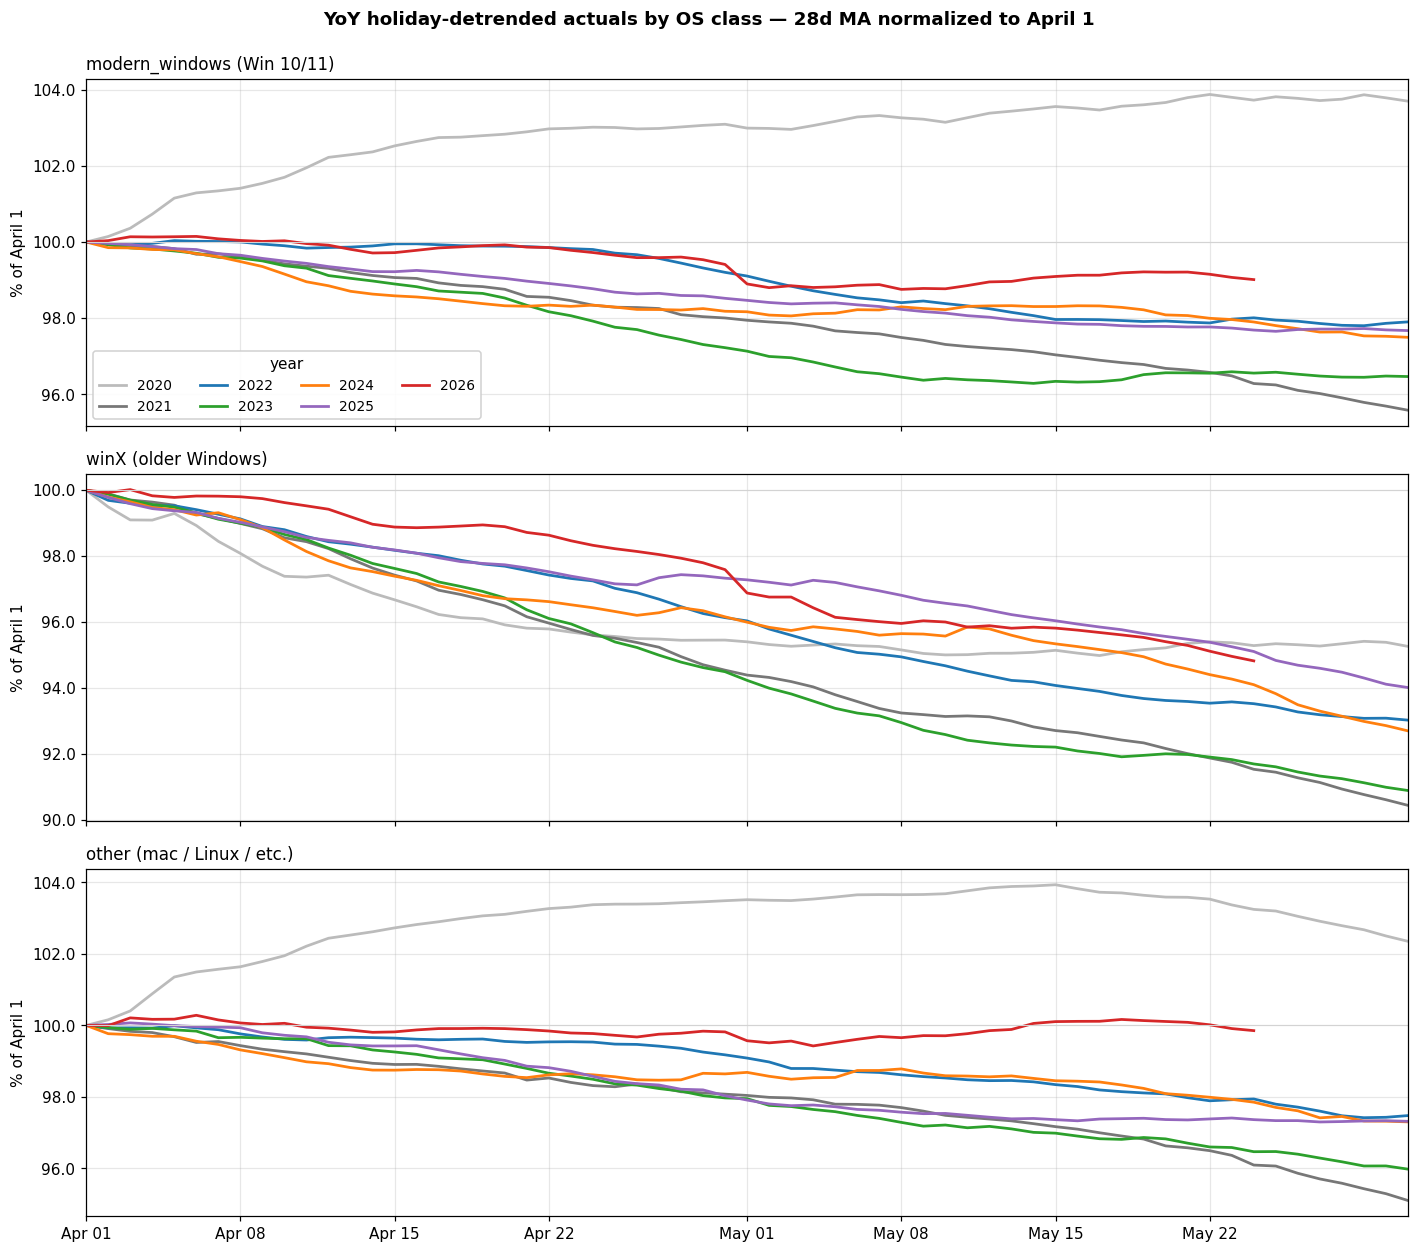

In [23]:
# [yoy-plot-by-os]
# Sum BQ actuals across countries for each OS class, then subtract per-OS
# holiday_smart aggregated from the matching tiles (population == os_class).
by_os = (
    hist_country_os.groupby(['date', 'os_class'], as_index=False)['dau']
    .sum()
)

OS_CLASSES = ['modern_windows', 'winX', 'other']
OS_LABELS = {'modern_windows': 'modern_windows (Win 10/11)',
             'winX': 'winX (older Windows)',
             'other': 'other (mac / Linux / etc.)'}

os_yoy = {}
for os_class in OS_CLASSES:
    raw = by_os[by_os['os_class'] == os_class].set_index('date')['dau'].sort_index()
    hs = build_segment_holiday_smart(
        metric_mozaic, lambda t, oc=os_class: t.population == oc
    )
    detrended = raw.subtract(hs.reindex(raw.index, fill_value=0))
    os_yoy[os_class] = {
        y: align_to_common_year(year_slice_28ma_normalized(detrended, y))
        for y in YEARS
    }

COMMON_X_START = pd.Timestamp(2024, 4, 1)
COMMON_X_END = pd.Timestamp(2024, 5, 31)

# Interactive — stacked vertically
fig = make_subplots(
    rows=len(OS_CLASSES), cols=1, shared_xaxes=True,
    subplot_titles=[OS_LABELS[c] for c in OS_CLASSES],
    vertical_spacing=0.07,
)
for row, os_class in enumerate(OS_CLASSES, start=1):
    for y in YEARS:
        s = os_yoy[os_class][y]
        if len(s):
            fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines',
                                      name=str(y), legendgroup=str(y),
                                      showlegend=(row == 1),
                                      line=dict(color=YEAR_COLORS[y], width=1.8)),
                          row=row, col=1)
    fig.add_hline(y=100, line=dict(color='lightgray', width=1), row=row, col=1)
fig.update_xaxes(range=[COMMON_X_START, COMMON_X_END])
fig.update_yaxes(tickformat='.1f', title='% of April 1')
fig.update_layout(
    title='YoY holiday-detrended actuals by OS class — 28d MA normalized to April 1',
    height=350 * len(OS_CLASSES), margin=dict(t=80, l=70, r=30, b=40),
    legend=dict(orientation='h', yanchor='bottom', y=1.03, xanchor='right', x=1, title='year'),
)
fig.show()

# Static — stacked vertically
fig_m, axes = plt.subplots(len(OS_CLASSES), 1, figsize=(13, 3.8 * len(OS_CLASSES)), sharex=True)
for ax, os_class in zip(axes, OS_CLASSES):
    for y in YEARS:
        s = os_yoy[os_class][y]
        if len(s):
            ax.plot(s.index, s.values, color=YEAR_COLORS[y], linewidth=1.8, label=str(y))
    ax.axhline(100, color='lightgray', linewidth=0.7)
    ax.set_title(OS_LABELS[os_class], loc='left', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('% of April 1')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
axes[0].legend(loc='lower left', fontsize=9, framealpha=0.9, title='year', ncol=4)
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].set_xlim(COMMON_X_START, COMMON_X_END)
fig_m.suptitle('YoY holiday-detrended actuals by OS class — 28d MA normalized to April 1',
               fontweight='bold', y=0.995)
fig_m.tight_layout()
plt.show()
plt.close(fig_m)


## 14. Year-over-year by country (holiday-detrended, mozaic-resolved)

Same YoY view, broken out by the 14 countries mozaic resolves individually plus the ROW bucket (everything else summed). Per-country holiday_smart is built by summing each tile's `(raw − detrended)` historical impacts and median forecasted impacts across all tiles with that country — so detrending uses each country's own holiday calendar (Easter for Christian countries, Diwali for IN, etc.). Grid layout: 5 rows × 3 columns.


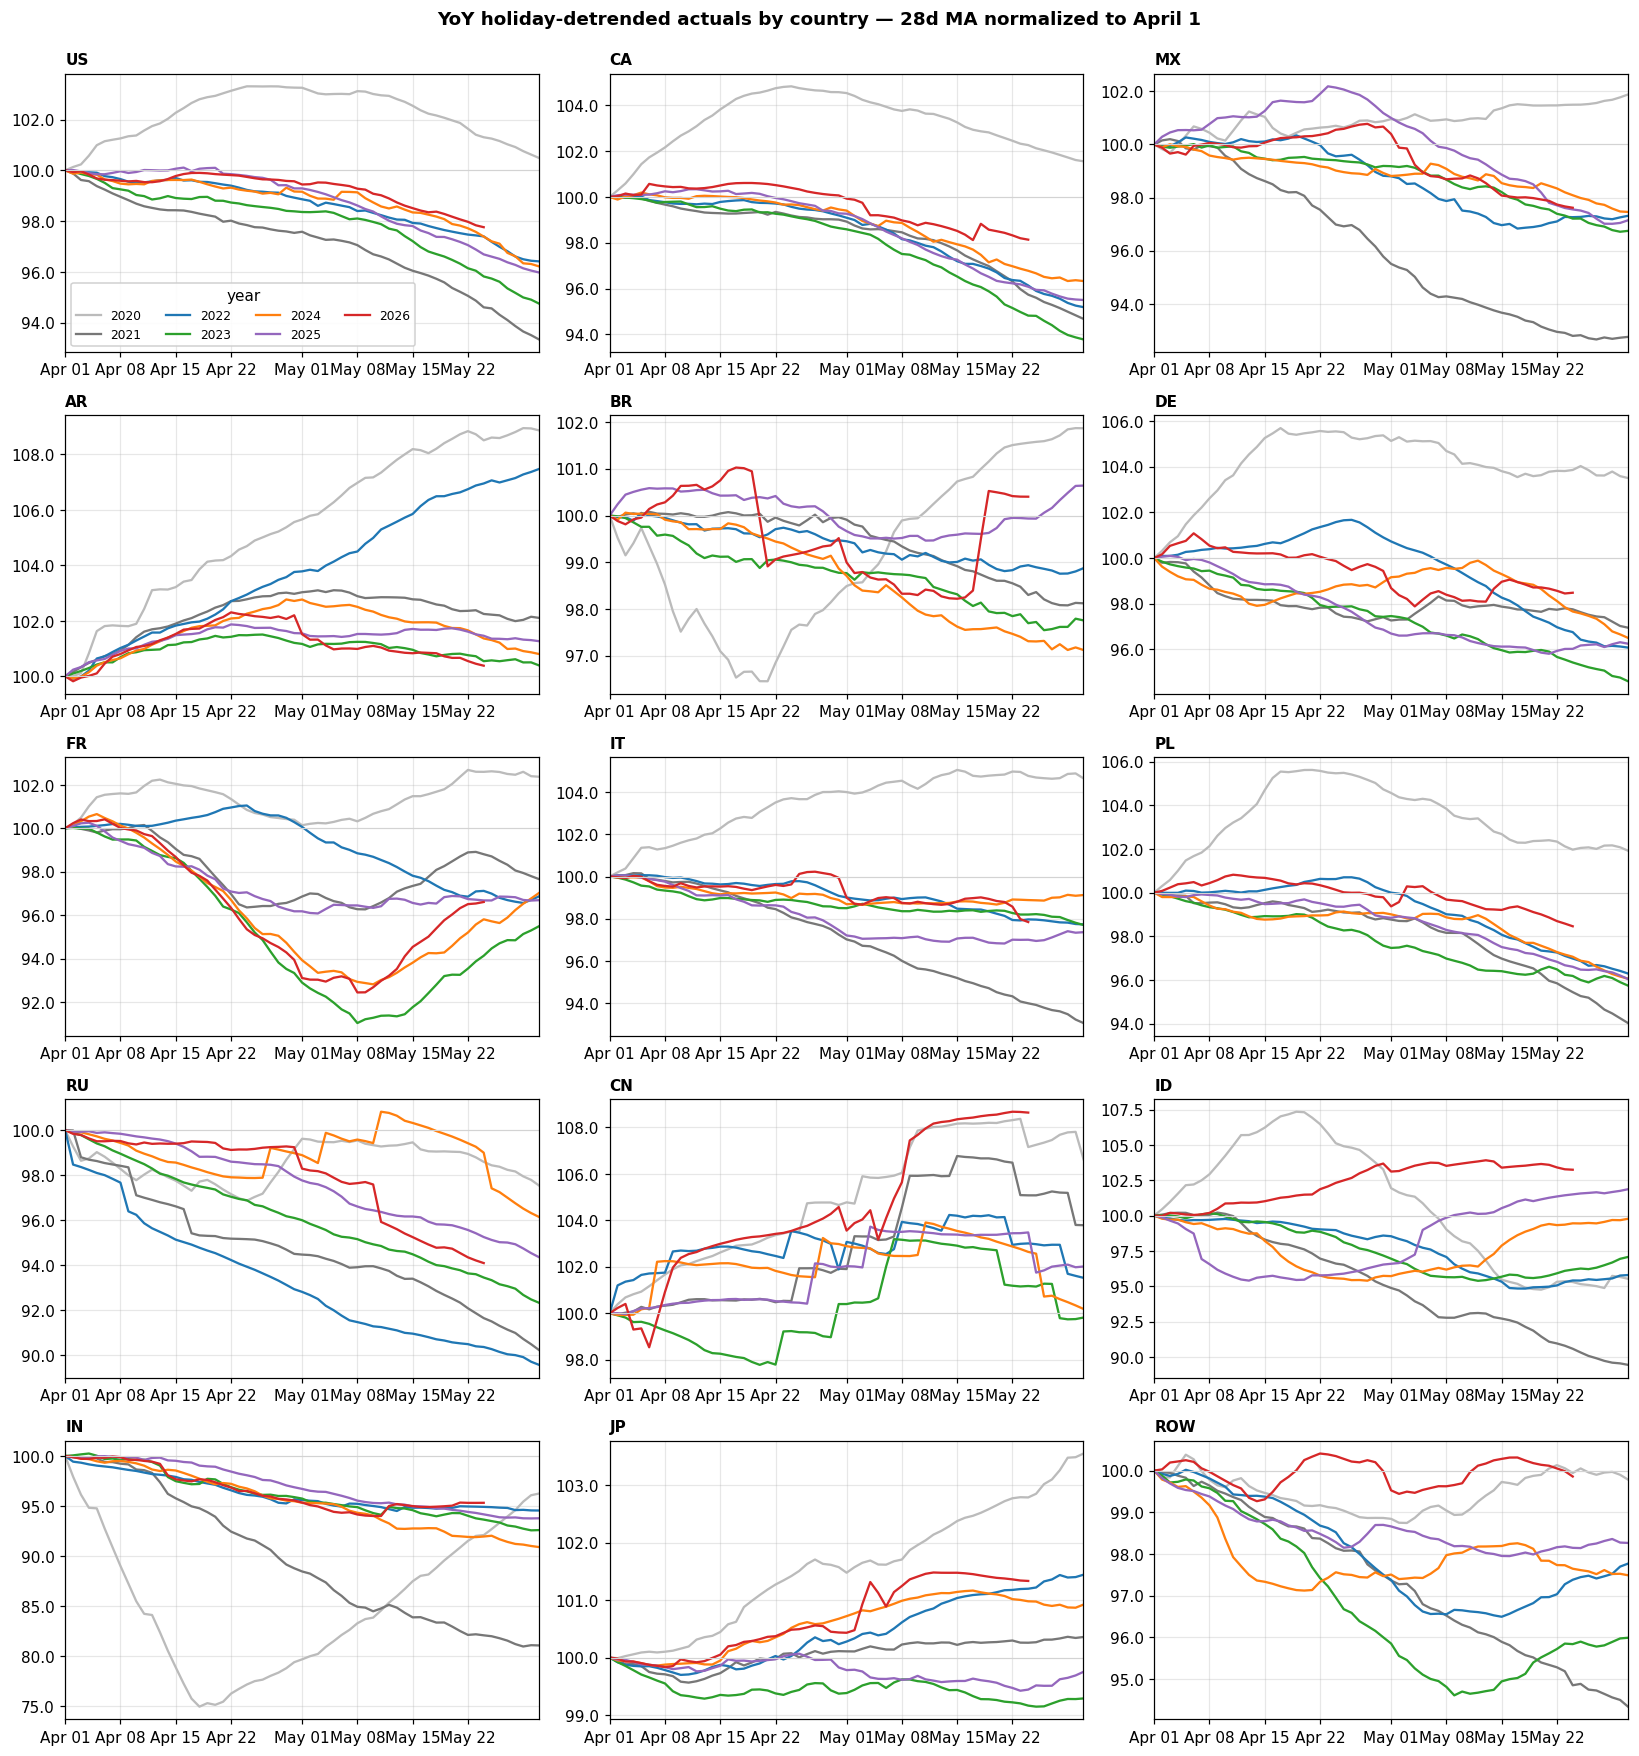

In [24]:
# [yoy-plot-by-country]
NAMED_COUNTRIES = ['US', 'CA', 'MX', 'AR', 'BR', 'DE', 'FR', 'IT', 'PL', 'RU', 'CN', 'ID', 'IN', 'JP']
COUNTRY_PANELS = NAMED_COUNTRIES + ['ROW']

hist_country_os['country_bucket'] = hist_country_os['country'].where(
    hist_country_os['country'].isin(NAMED_COUNTRIES), 'ROW'
)
by_country = (
    hist_country_os.groupby(['date', 'country_bucket'], as_index=False)['dau']
    .sum()
)

country_yoy = {}
for c in COUNTRY_PANELS:
    raw = by_country[by_country['country_bucket'] == c].set_index('date')['dau'].sort_index()
    if c == 'ROW':
        hs = build_segment_holiday_smart(
            metric_mozaic, lambda t: t.country not in NAMED_COUNTRIES
        )
    else:
        hs = build_segment_holiday_smart(
            metric_mozaic, lambda t, country=c: t.country == country
        )
    detrended = raw.subtract(hs.reindex(raw.index, fill_value=0))
    country_yoy[c] = {
        y: align_to_common_year(year_slice_28ma_normalized(detrended, y))
        for y in YEARS
    }

N_COLS = 3
N_ROWS = (len(COUNTRY_PANELS) + N_COLS - 1) // N_COLS

# Interactive
fig = make_subplots(
    rows=N_ROWS, cols=N_COLS, shared_yaxes=False,
    subplot_titles=COUNTRY_PANELS,
    horizontal_spacing=0.05, vertical_spacing=0.05,
)
for idx, country in enumerate(COUNTRY_PANELS):
    row, col = idx // N_COLS + 1, idx % N_COLS + 1
    for y in YEARS:
        s = country_yoy[country][y]
        if len(s):
            fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines',
                                      name=str(y), legendgroup=str(y),
                                      showlegend=(idx == 0),
                                      line=dict(color=YEAR_COLORS[y], width=1.5)),
                          row=row, col=col)
    fig.add_hline(y=100, line=dict(color='lightgray', width=1), row=row, col=col)
    fig.update_xaxes(range=[COMMON_X_START, COMMON_X_END], row=row, col=col)
fig.update_layout(
    title='YoY holiday-detrended actuals by country (mozaic resolution) — 28d MA normalized to April 1',
    height=260 * N_ROWS, margin=dict(t=80, l=60, r=30, b=40),
    legend=dict(orientation='h', yanchor='bottom', y=1.03, xanchor='right', x=1, title='year'),
)
fig.update_yaxes(tickformat='.1f')
fig.show()

# Static
fig_m, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 3.2 * N_ROWS), sharey=False)
axes_flat = axes.flatten()
for idx, country in enumerate(COUNTRY_PANELS):
    ax = axes_flat[idx]
    for y in YEARS:
        s = country_yoy[country][y]
        if len(s):
            ax.plot(s.index, s.values, color=YEAR_COLORS[y], linewidth=1.5, label=str(y))
    ax.axhline(100, color='lightgray', linewidth=0.7)
    ax.set_title(country, loc='left', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(COMMON_X_START, COMMON_X_END)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
for j in range(len(COUNTRY_PANELS), N_ROWS * N_COLS):
    axes_flat[j].set_visible(False)
axes_flat[0].legend(loc='lower left', fontsize=8, framealpha=0.9, title='year', ncol=4)
fig_m.suptitle('YoY holiday-detrended actuals by country — 28d MA normalized to April 1',
               fontweight='bold', y=0.995)
fig_m.tight_layout()
plt.show()
plt.close(fig_m)


## 15. Jan 1 → today YoY (holiday-detrended, world-level)

Longer-window YoY: each year's 28d MA from Jan 1 through the same month/day as today (so all 7 years are compared on the same calendar window). Normalized so each year's Jan 1 28d MA = 100. World-level, holiday-detrended (= `unified_actuals − holiday_smart`, same series Prophet was fit on for historical dates).

**Why this view.** The §12 April–May window is too narrow to see whether the recent flattening of April→May is part of a broader change in the seasonal shape, or just a localized effect in those two months. Looking at Jan→today shows the full Q1+Q2 trajectory side-by-side across years.

**Note on 2020.** The metric mozaic's historical data starts 2020-01-01, so the 28d MA needs Dec 2019 data that isn't available; 2020's line will start at Jan 28 (its first computable 28d MA) and normalize to its Jan 28 value. The other years (2021+) include Dec data and properly normalize to Jan 1.

Anchor: Jan 1 of each year; end: 05-24 (today in 2026)


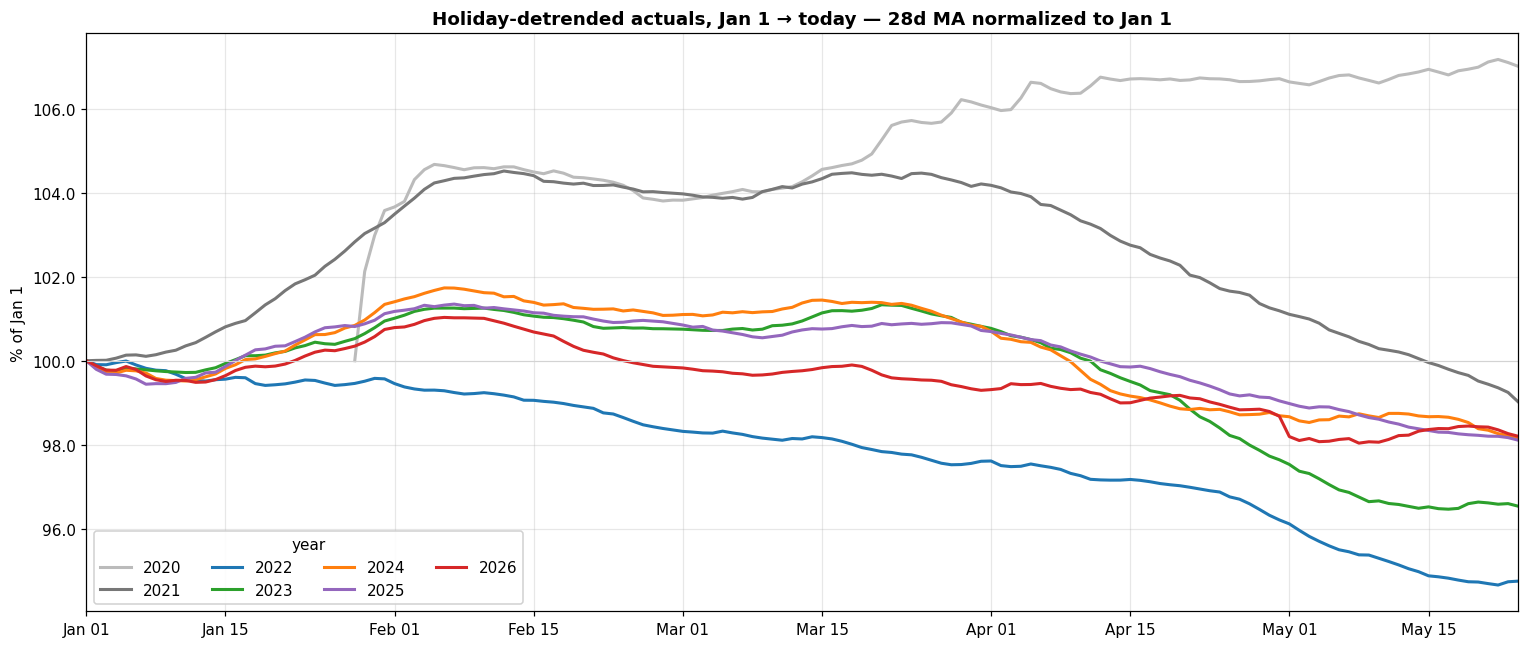


Summary (% change from Jan 1 to end-of-window, 28d MA):
  2020: 100.00 → 107.01  ( +7.01%)
  2021: 100.00 →  99.03  ( -0.97%)
  2022: 100.00 →  94.75  ( -5.25%)
  2023: 100.00 →  96.54  ( -3.46%)
  2024: 100.00 →  98.14  ( -1.86%)
  2025: 100.00 →  98.11  ( -1.89%)
  2026: 100.00 →  98.20  ( -1.80%)


In [25]:
# [yoy-jan-to-now]
# End at the last available date in the unified series (current 'today' from the
# BQ actuals query).
_today = unified_detrended.index.max()
END_M, END_D = _today.month, _today.day
print(f'Anchor: Jan 1 of each year; end: {END_M:02d}-{END_D:02d} (today in 2026)')

actuals_full_yoy = {
    y: align_to_common_year(year_slice_28ma_normalized(
        unified_detrended, y,
        anchor_month=1, anchor_day=1,
        end_month=END_M, end_day=END_D,
    )) for y in YEARS
}

FULL_X_START = pd.Timestamp(2024, 1, 1)
FULL_X_END = pd.Timestamp(2024, END_M, END_D)

# Interactive
fig = go.Figure()
for y in YEARS:
    s = actuals_full_yoy[y]
    if len(s):
        fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines', name=str(y),
                                  line=dict(color=YEAR_COLORS[y], width=2)))
fig.add_hline(y=100, line=dict(color='lightgray', width=1))
fig.update_layout(
    title='Holiday-detrended actuals, Jan 1 → today — 28d MA normalized to Jan 1',
    height=540, margin=dict(t=80, l=70, r=30, b=40),
    legend=dict(orientation='h', yanchor='bottom', y=1.03, xanchor='right', x=1, title='year'),
)
fig.update_xaxes(range=[FULL_X_START, FULL_X_END])
fig.update_yaxes(title='% of Jan 1', tickformat='.1f')
fig.show()

# Static
fig_m, ax = plt.subplots(figsize=(14, 6))
for y in YEARS:
    s = actuals_full_yoy[y]
    if len(s):
        ax.plot(s.index, s.values, color=YEAR_COLORS[y], linewidth=2, label=str(y))
ax.axhline(100, color='lightgray', linewidth=0.7)
ax.set_xlim(FULL_X_START, FULL_X_END)
ax.set_ylabel('% of Jan 1')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
ax.legend(loc='lower left', fontsize=10, framealpha=0.9, title='year', ncol=4)
ax.grid(True, alpha=0.3)
ax.set_title('Holiday-detrended actuals, Jan 1 → today — 28d MA normalized to Jan 1',
             fontweight='bold')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

print('\nSummary (% change from Jan 1 to end-of-window, 28d MA):')
for y in YEARS:
    s = actuals_full_yoy[y]
    if len(s):
        print(f'  {y}: {s.iloc[0]:6.2f} → {s.iloc[-1]:6.2f}  ({s.iloc[-1] - s.iloc[0]:+6.2f}%)')